# Asteroid Mass, Density, and Size Distributions

This notebook explores the physical properties of asteroids using two datasets:

1. **SBN Archive Asteroid Masses** (~248 asteroids with mass, density, and tri-axial shape data)
2. **JPL Small Body Database (SBDB)** (~875,000 asteroids with orbital elements, diameter, and GM)

We visualize distributions of:

- **Mass** (log-scale histogram)
- **Bulk density** (linear histogram)
- **Equivalent radius** (log-scale histogram)
- **Mass vs. size** (scatter plot with density-based reference line)
- **SBDB diameter and GM distributions** (large-population statistics)
- **Combined mass–radius comparison** across both datasets

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scienceplots  # noqa: F401

from astrojax.datasets import load_asteroid_masses, load_sbdb_asteroids

plt.style.use(["science", "ieee"])

## Load Dataset

The SBN Archive compilation contains mass, density, and tri-axial shape data
for ~248 asteroids. Not all fields are available for every asteroid.

In [2]:
df = load_asteroid_masses()

print(f"Total records: {df.shape[0]}")
print("\nNon-null counts per column:")
for col in df.columns:
    n_valid = df[col].drop_nulls().len()
    print(f"  {col:<20} {n_valid:>5}")

Total records: 248

Non-null counts per column:
  ast_number             248
  ast_name               248
  prov_desig             248
  satellite_name         248
  mass_sol               248
  mass_sol_unc           248
  mass_kg                248
  mass_kg_unc            248
  bulk_density           248
  bulk_density_unc       248
  axis_a                 248
  axis_b                 248
  axis_c                 248
  equiv_radius_unc       248
  mass_ref               248


## Mass Distribution

Asteroid masses in the `mass_kg` column are in kg.
The range spans several orders of magnitude, so a $\log_{10}$ histogram
is appropriate.

/tmp/ipykernel_3335743/3888097173.py:4: RuntimeWarning: invalid value encountered in log10
  log_mass = np.log10(mass_kg)


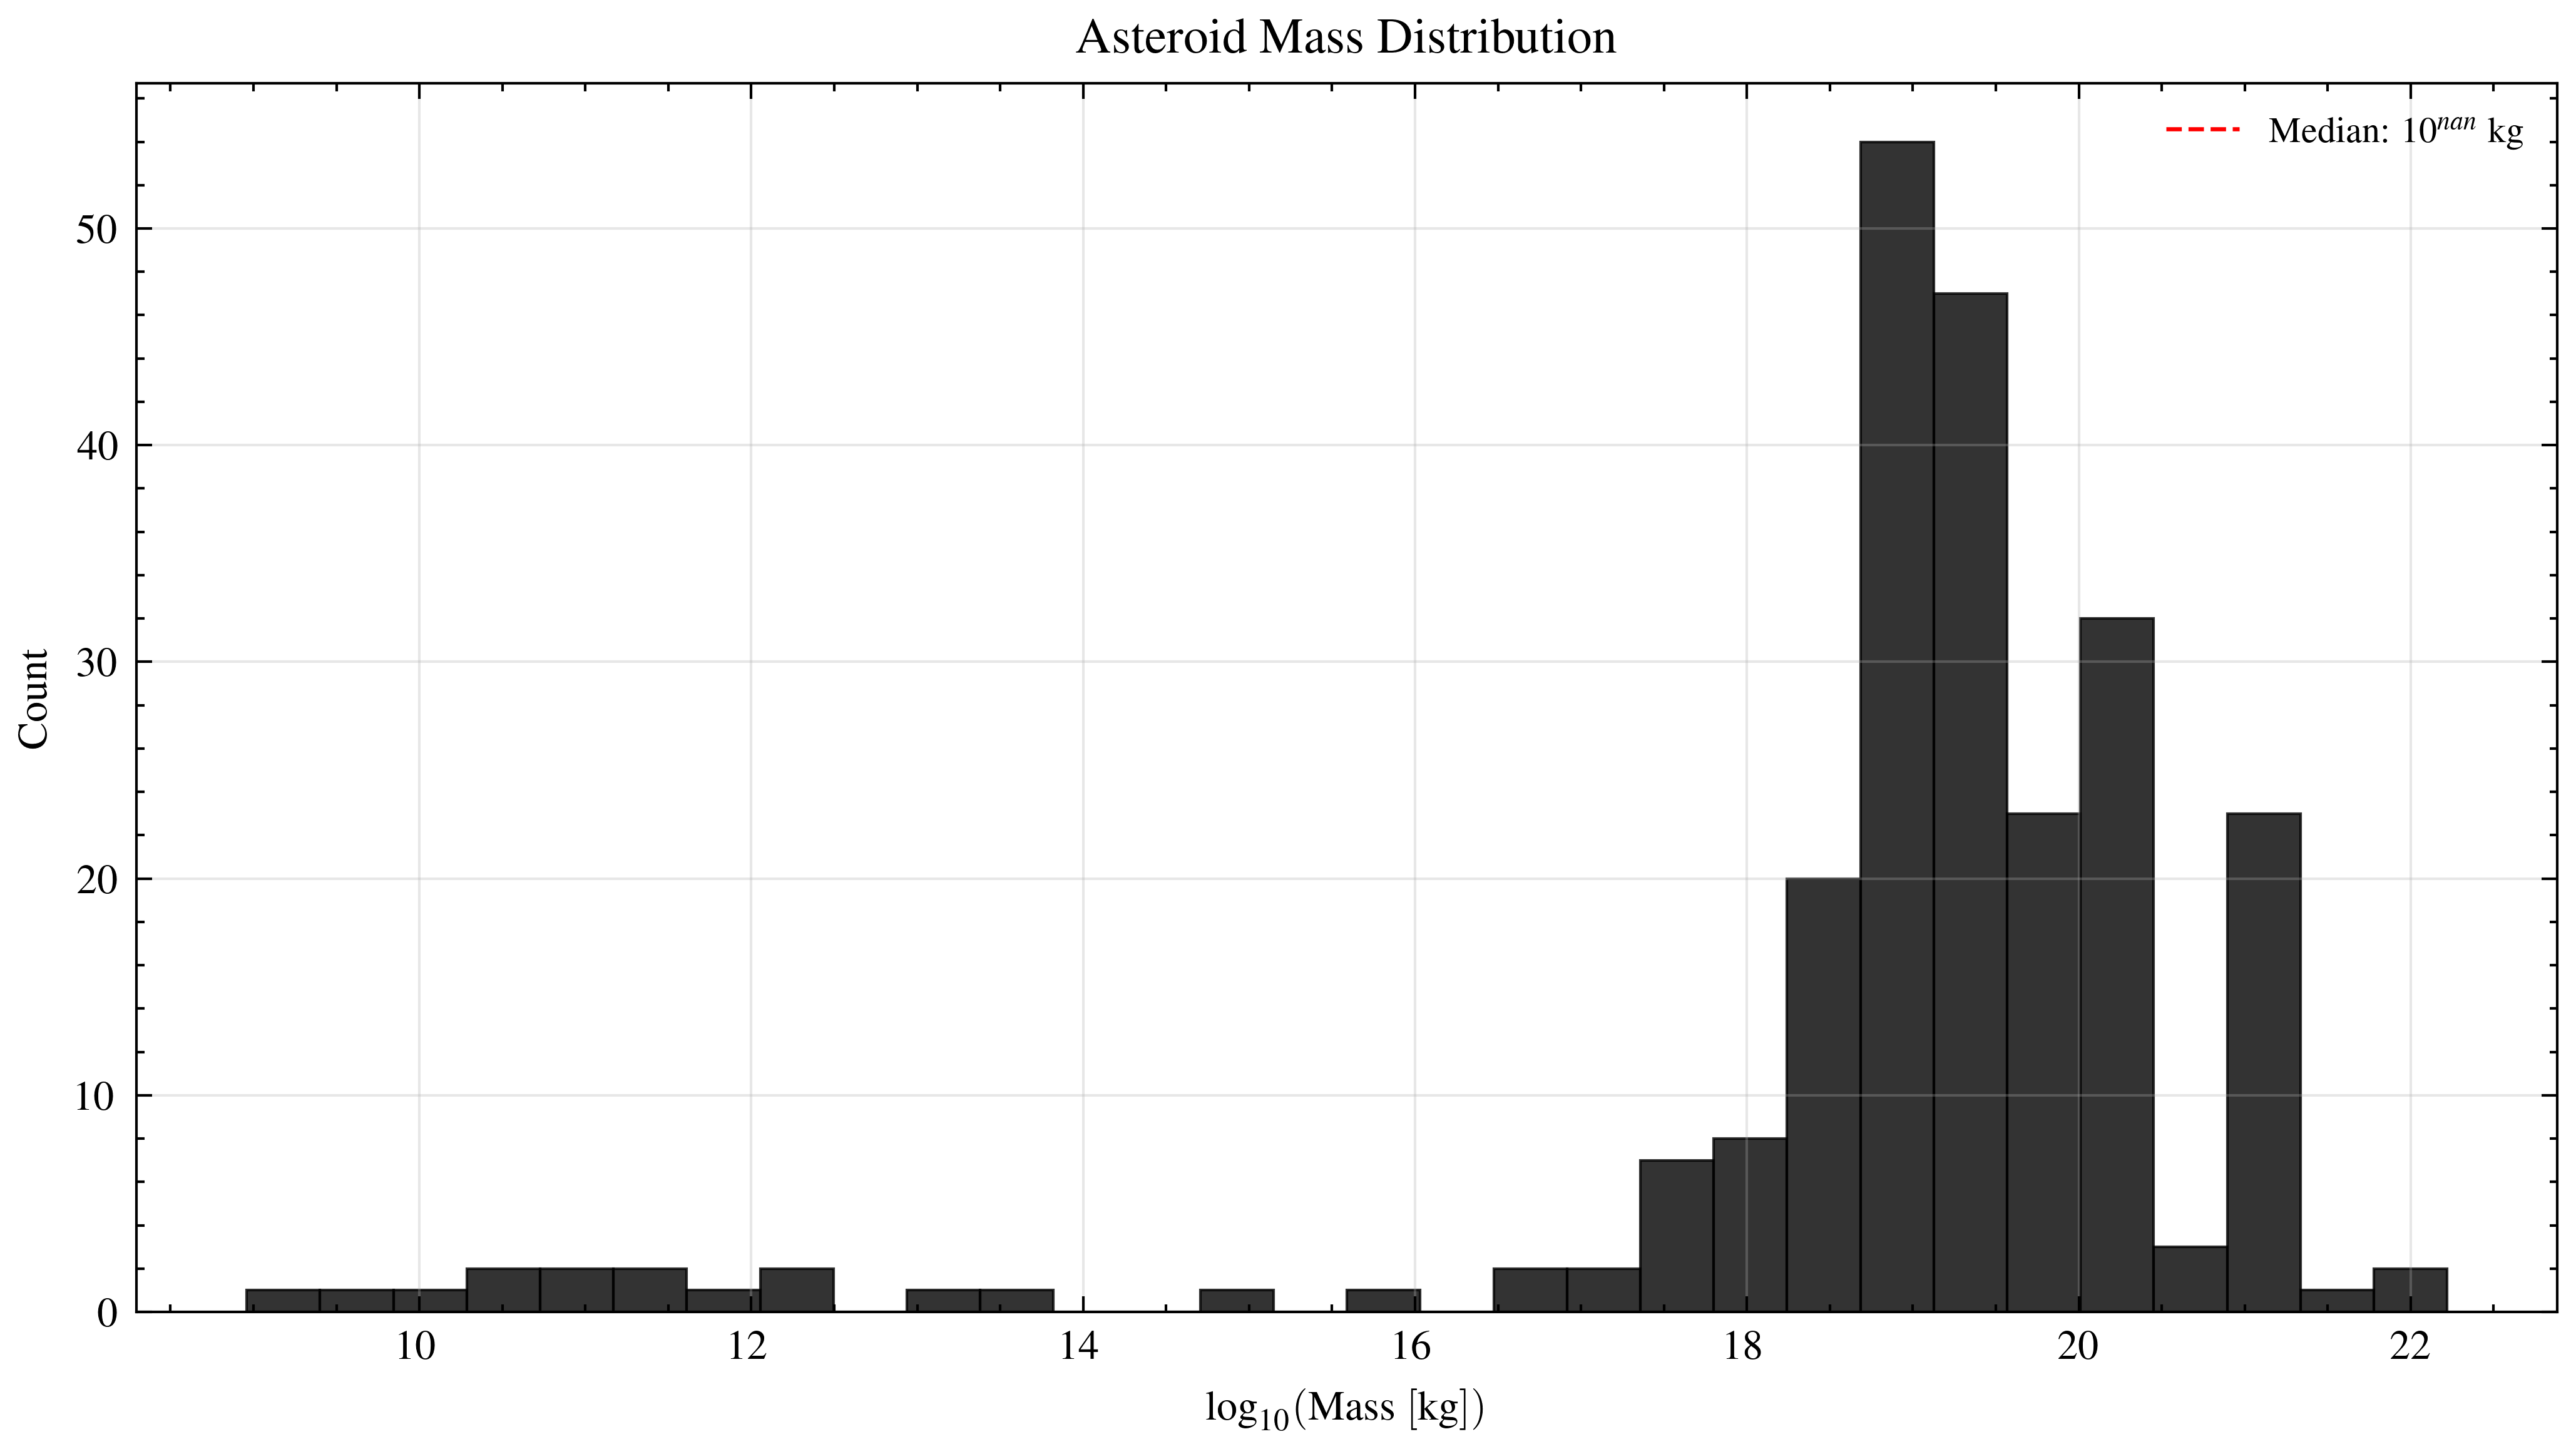

Asteroids with mass data: 248
Mass range: -9.90e-100 to 1.66e+22 kg


In [3]:
# Filter to asteroids with known mass
df_mass = df.filter(pl.col("mass_kg").is_not_null())
mass_kg = df_mass["mass_kg"].to_numpy()
log_mass = np.log10(mass_kg)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(log_mass, bins=30, edgecolor="k", linewidth=0.5, alpha=0.8)
median_log = np.median(log_mass)
ax.axvline(
    median_log,
    color="red",
    linestyle="--",
    linewidth=0.8,
    label=f"Median: $10^{{{median_log:.1f}}}$ kg",
)
ax.set_xlabel(r"$\log_{10}(\mathrm{Mass\ [kg]})$")
ax.set_ylabel("Count")
ax.set_title("Asteroid Mass Distribution")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Asteroids with mass data: {len(mass_kg)}")
print(f"Mass range: {mass_kg.min():.2e} to {mass_kg.max():.2e} kg")

## Bulk Density Distribution

Bulk density in the dataset is in g/cm$^3$; we convert to kg/m$^3$ for
plotting.  Typical asteroid densities range from ~1000 kg/m$^3$
(ice-rich/porous C-types) to ~5000+ kg/m$^3$ (metallic M-types).

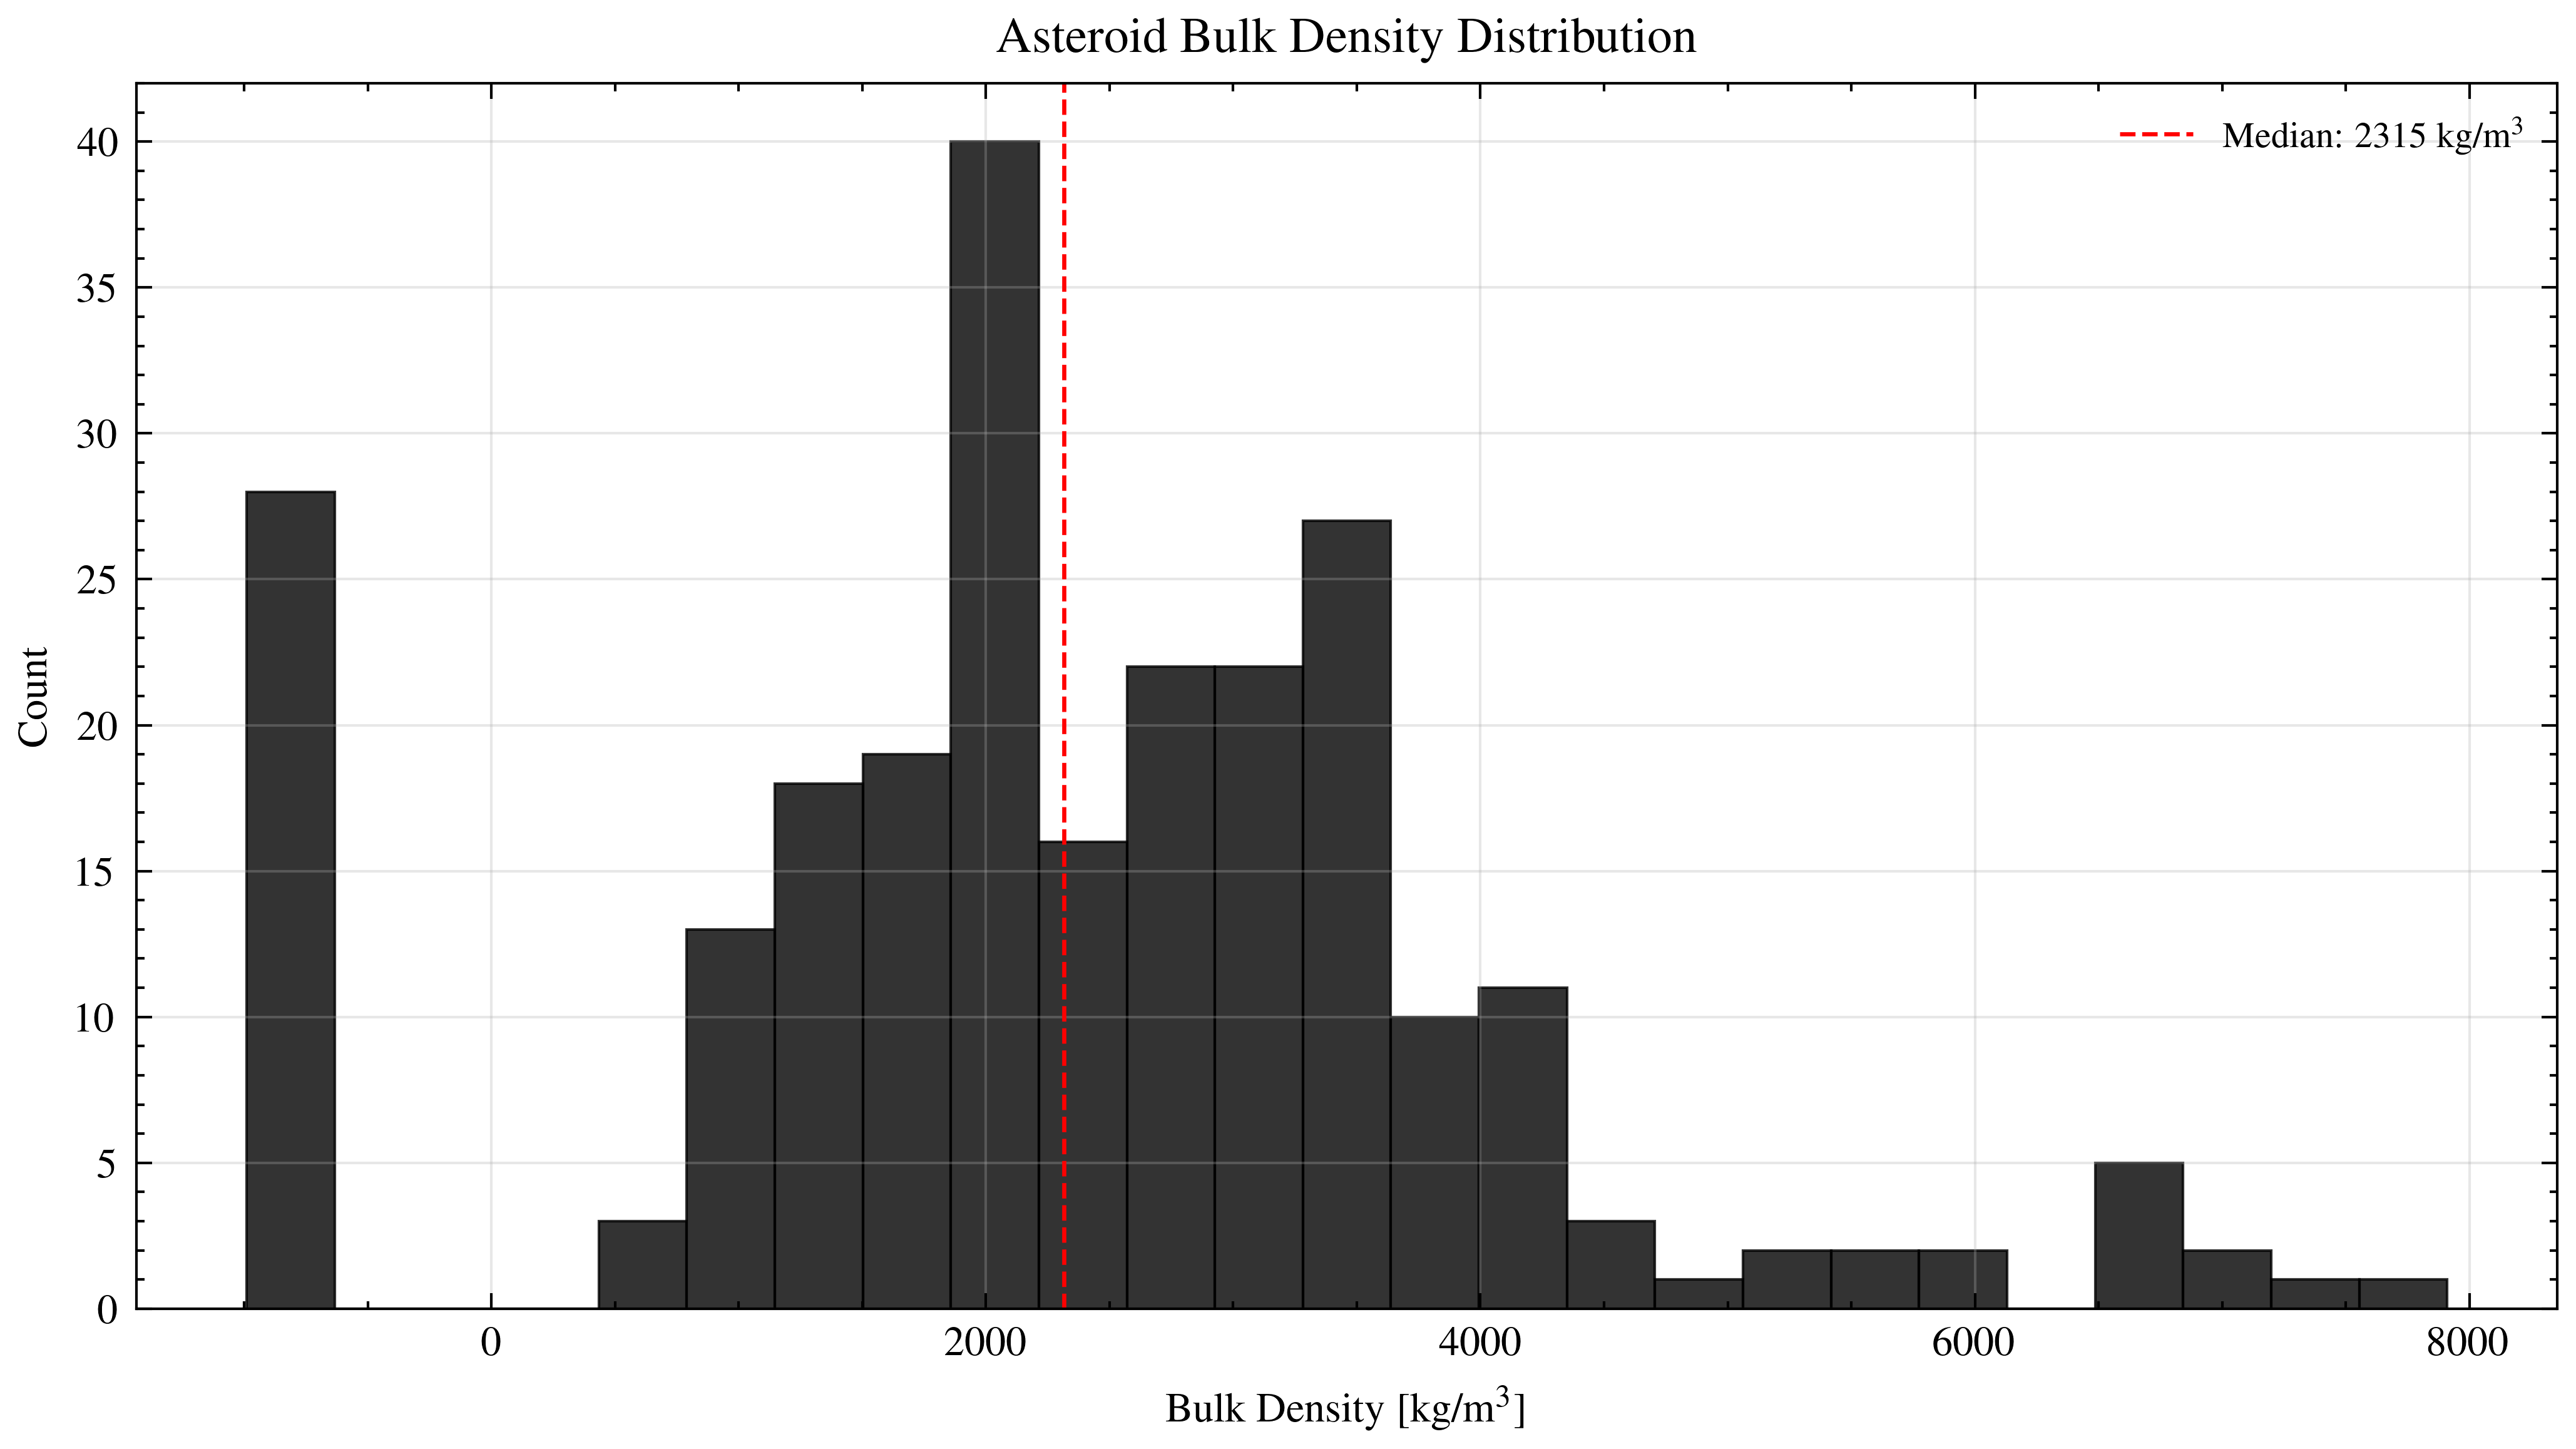

Asteroids with density data: 248
Density range: -990 to 7910 kg/m^3


In [4]:
df_density = df.filter(pl.col("bulk_density").is_not_null())
density = df_density["bulk_density"].to_numpy() * 1000.0  # g/cm^3 -> kg/m^3

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(density, bins=25, edgecolor="k", linewidth=0.5, alpha=0.8)
median_rho = np.median(density)
ax.axvline(
    median_rho,
    color="red",
    linestyle="--",
    linewidth=0.8,
    label=f"Median: {median_rho:.0f} kg/m$^3$",
)
ax.set_xlabel(r"Bulk Density [kg/m$^3$]")
ax.set_ylabel("Count")
ax.set_title("Asteroid Bulk Density Distribution")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Asteroids with density data: {len(density)}")
print(f"Density range: {density.min():.0f} to {density.max():.0f} kg/m^3")

## Size Distribution

Tri-axial ellipsoid diameters ($a$, $b$, $c$) are given in km. We compute
the equivalent spherical radius as $R_{\mathrm{eq}} = \frac{1}{2}(a \cdot b \cdot c)^{1/3}$.

/tmp/ipykernel_3335743/715148527.py:9: RuntimeWarning: invalid value encountered in power
  R_eq = (a * b * c) ** (1.0 / 3.0) / 2.0


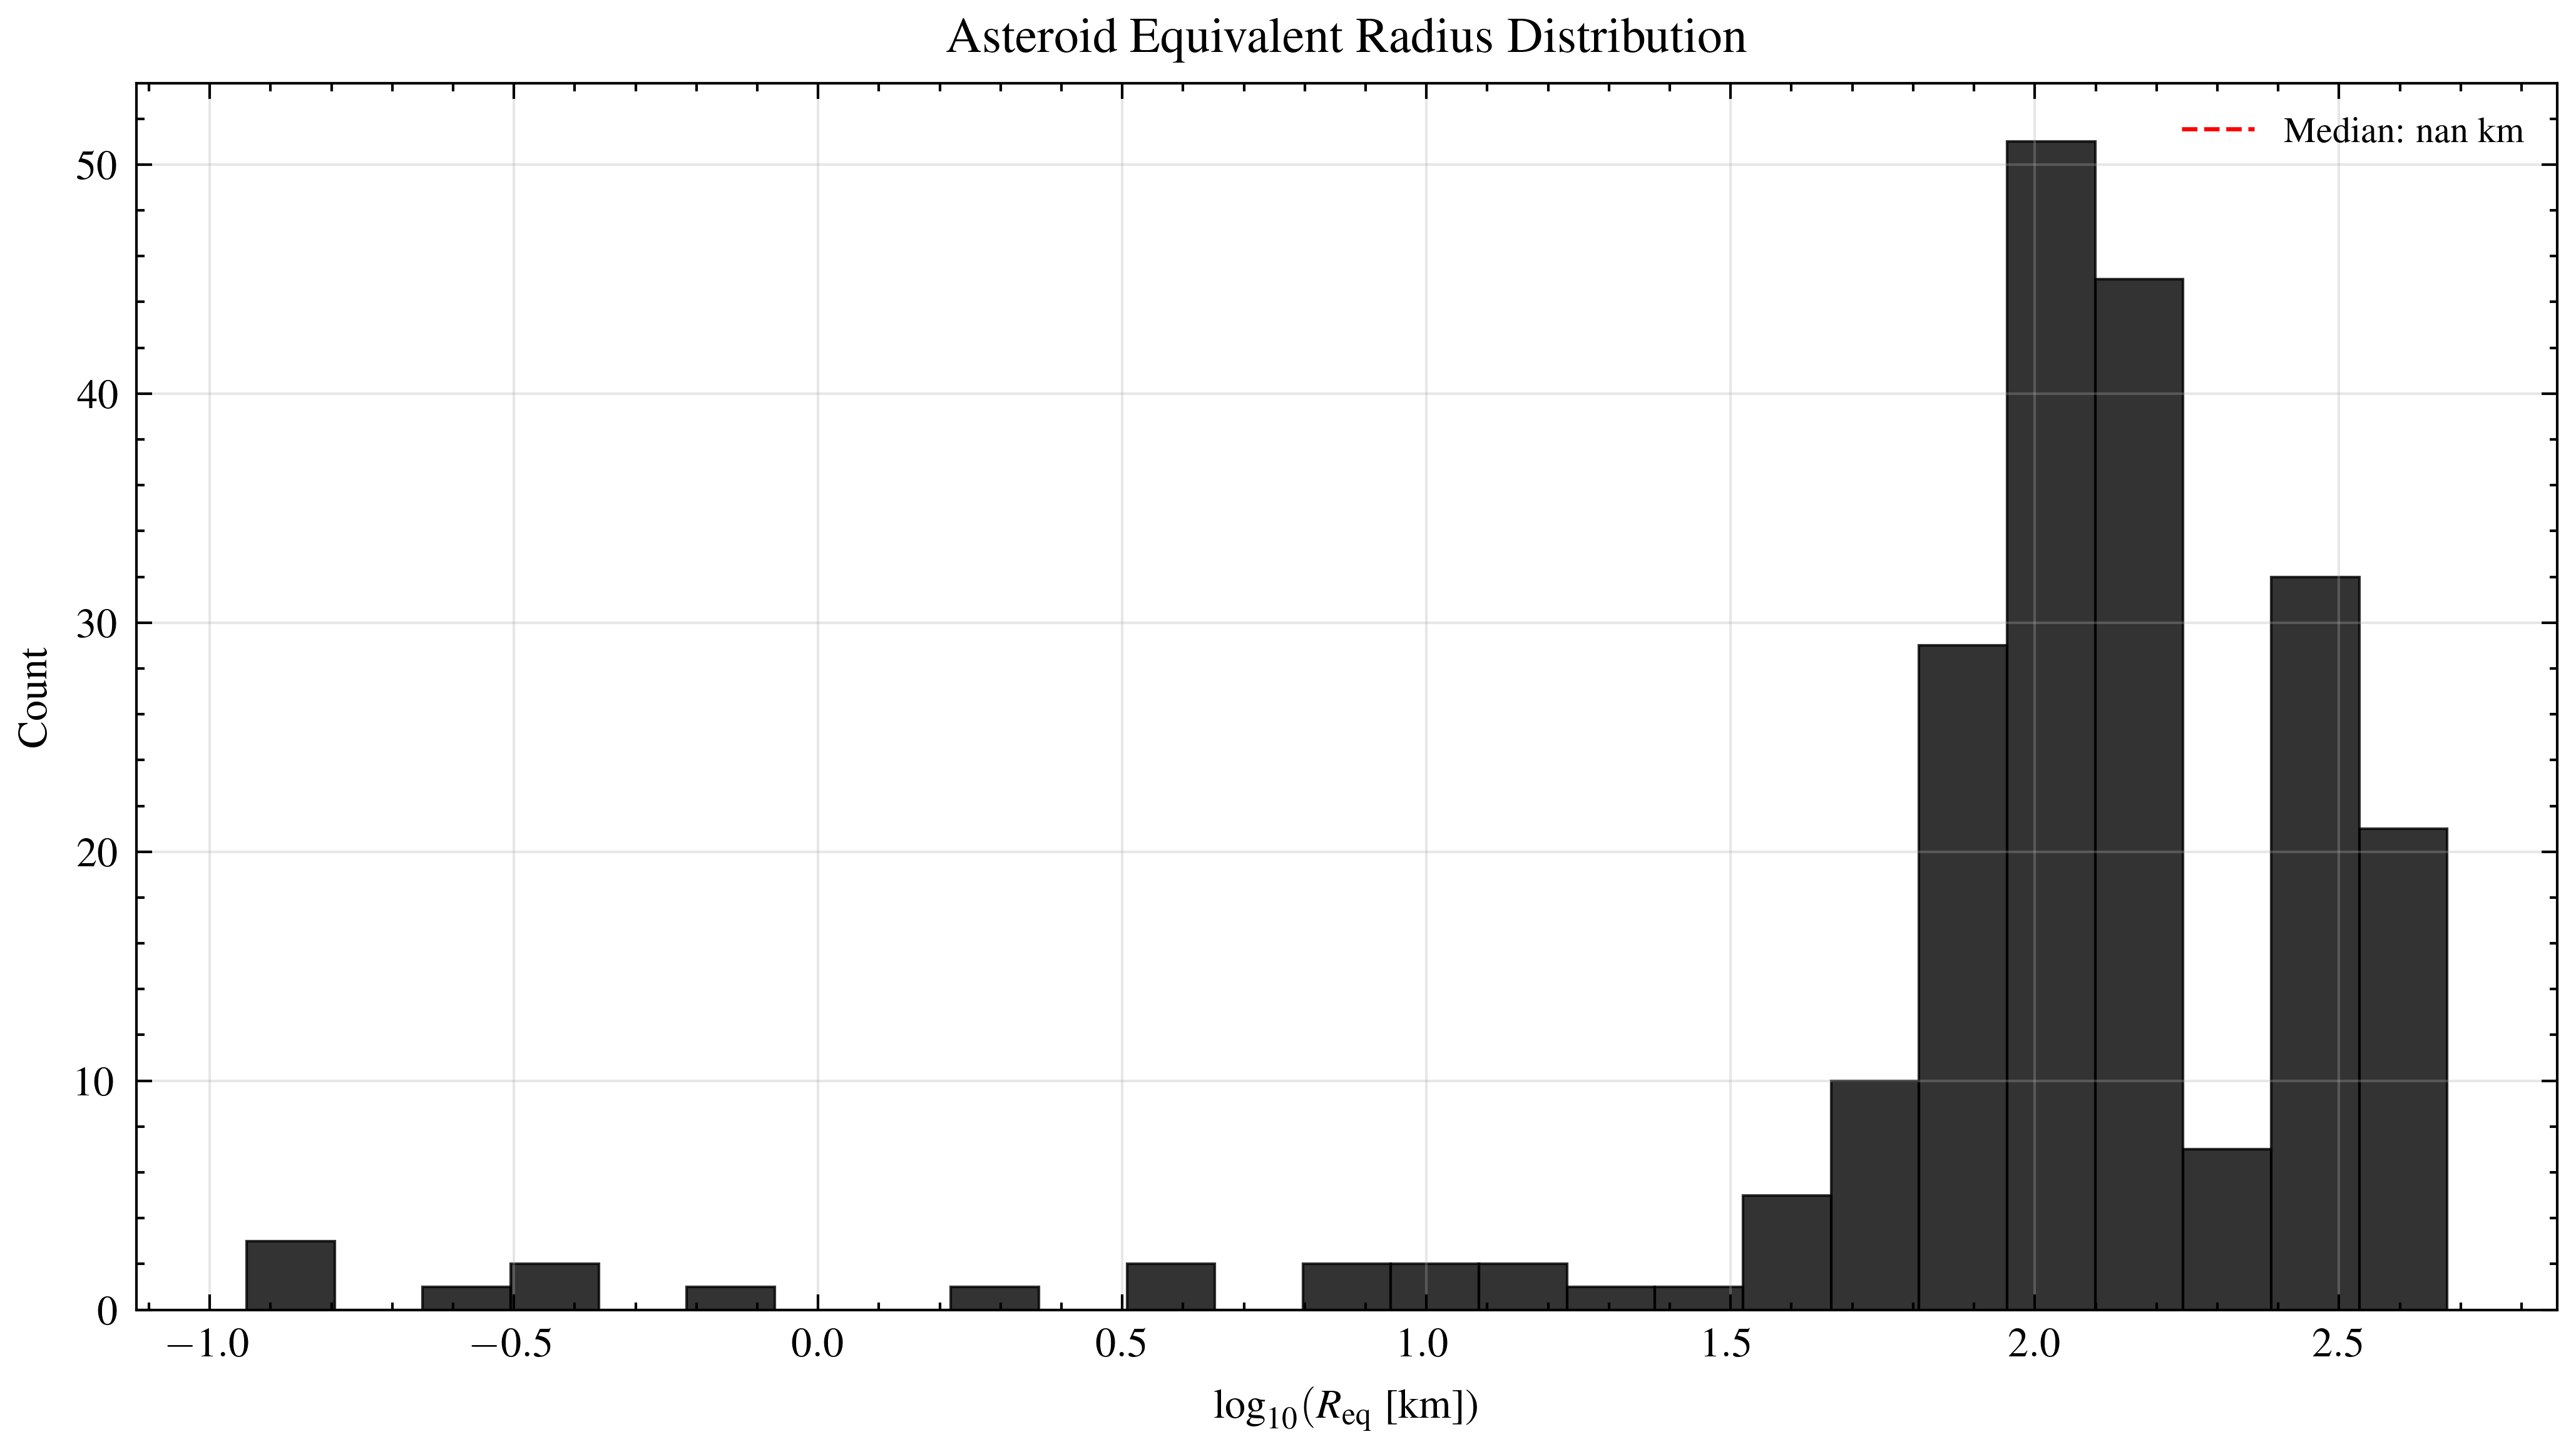

Asteroids with shape data: 248
Radius range: nan to nan km


In [5]:
df_shape = df.filter(
    pl.col("axis_a").is_not_null() & pl.col("axis_b").is_not_null() & pl.col("axis_c").is_not_null()
)
a = df_shape["axis_a"].to_numpy()
b = df_shape["axis_b"].to_numpy()
c = df_shape["axis_c"].to_numpy()

# Equivalent spherical radius [km] (axes are diameters, divide by 2)
R_eq = (a * b * c) ** (1.0 / 3.0) / 2.0
log_R = np.log10(R_eq)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(log_R, bins=25, edgecolor="k", linewidth=0.5, alpha=0.8)
median_log_R = np.median(log_R)
ax.axvline(
    median_log_R,
    color="red",
    linestyle="--",
    linewidth=0.8,
    label=f"Median: {10**median_log_R:.1f} km",
)
ax.set_xlabel(r"$\log_{10}(R_{\mathrm{eq}}$ [km])")
ax.set_ylabel("Count")
ax.set_title("Asteroid Equivalent Radius Distribution")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Asteroids with shape data: {len(R_eq)}")
print(f"Radius range: {R_eq.min():.1f} to {R_eq.max():.1f} km")

## Mass vs. Size

Scatter plot of mass versus equivalent radius, colored by bulk density
where available. A reference line shows the expected relationship
$M = \frac{4}{3}\pi \rho R^3$ for $\rho = 2500$ kg/m$^3$ (typical S-type asteroid).

/tmp/ipykernel_3335743/955726560.py:13: RuntimeWarning: invalid value encountered in power
  R_both = (a_both * b_both * c_both) ** (1.0 / 3.0) / 2.0  # radius in km (axes are diameters)


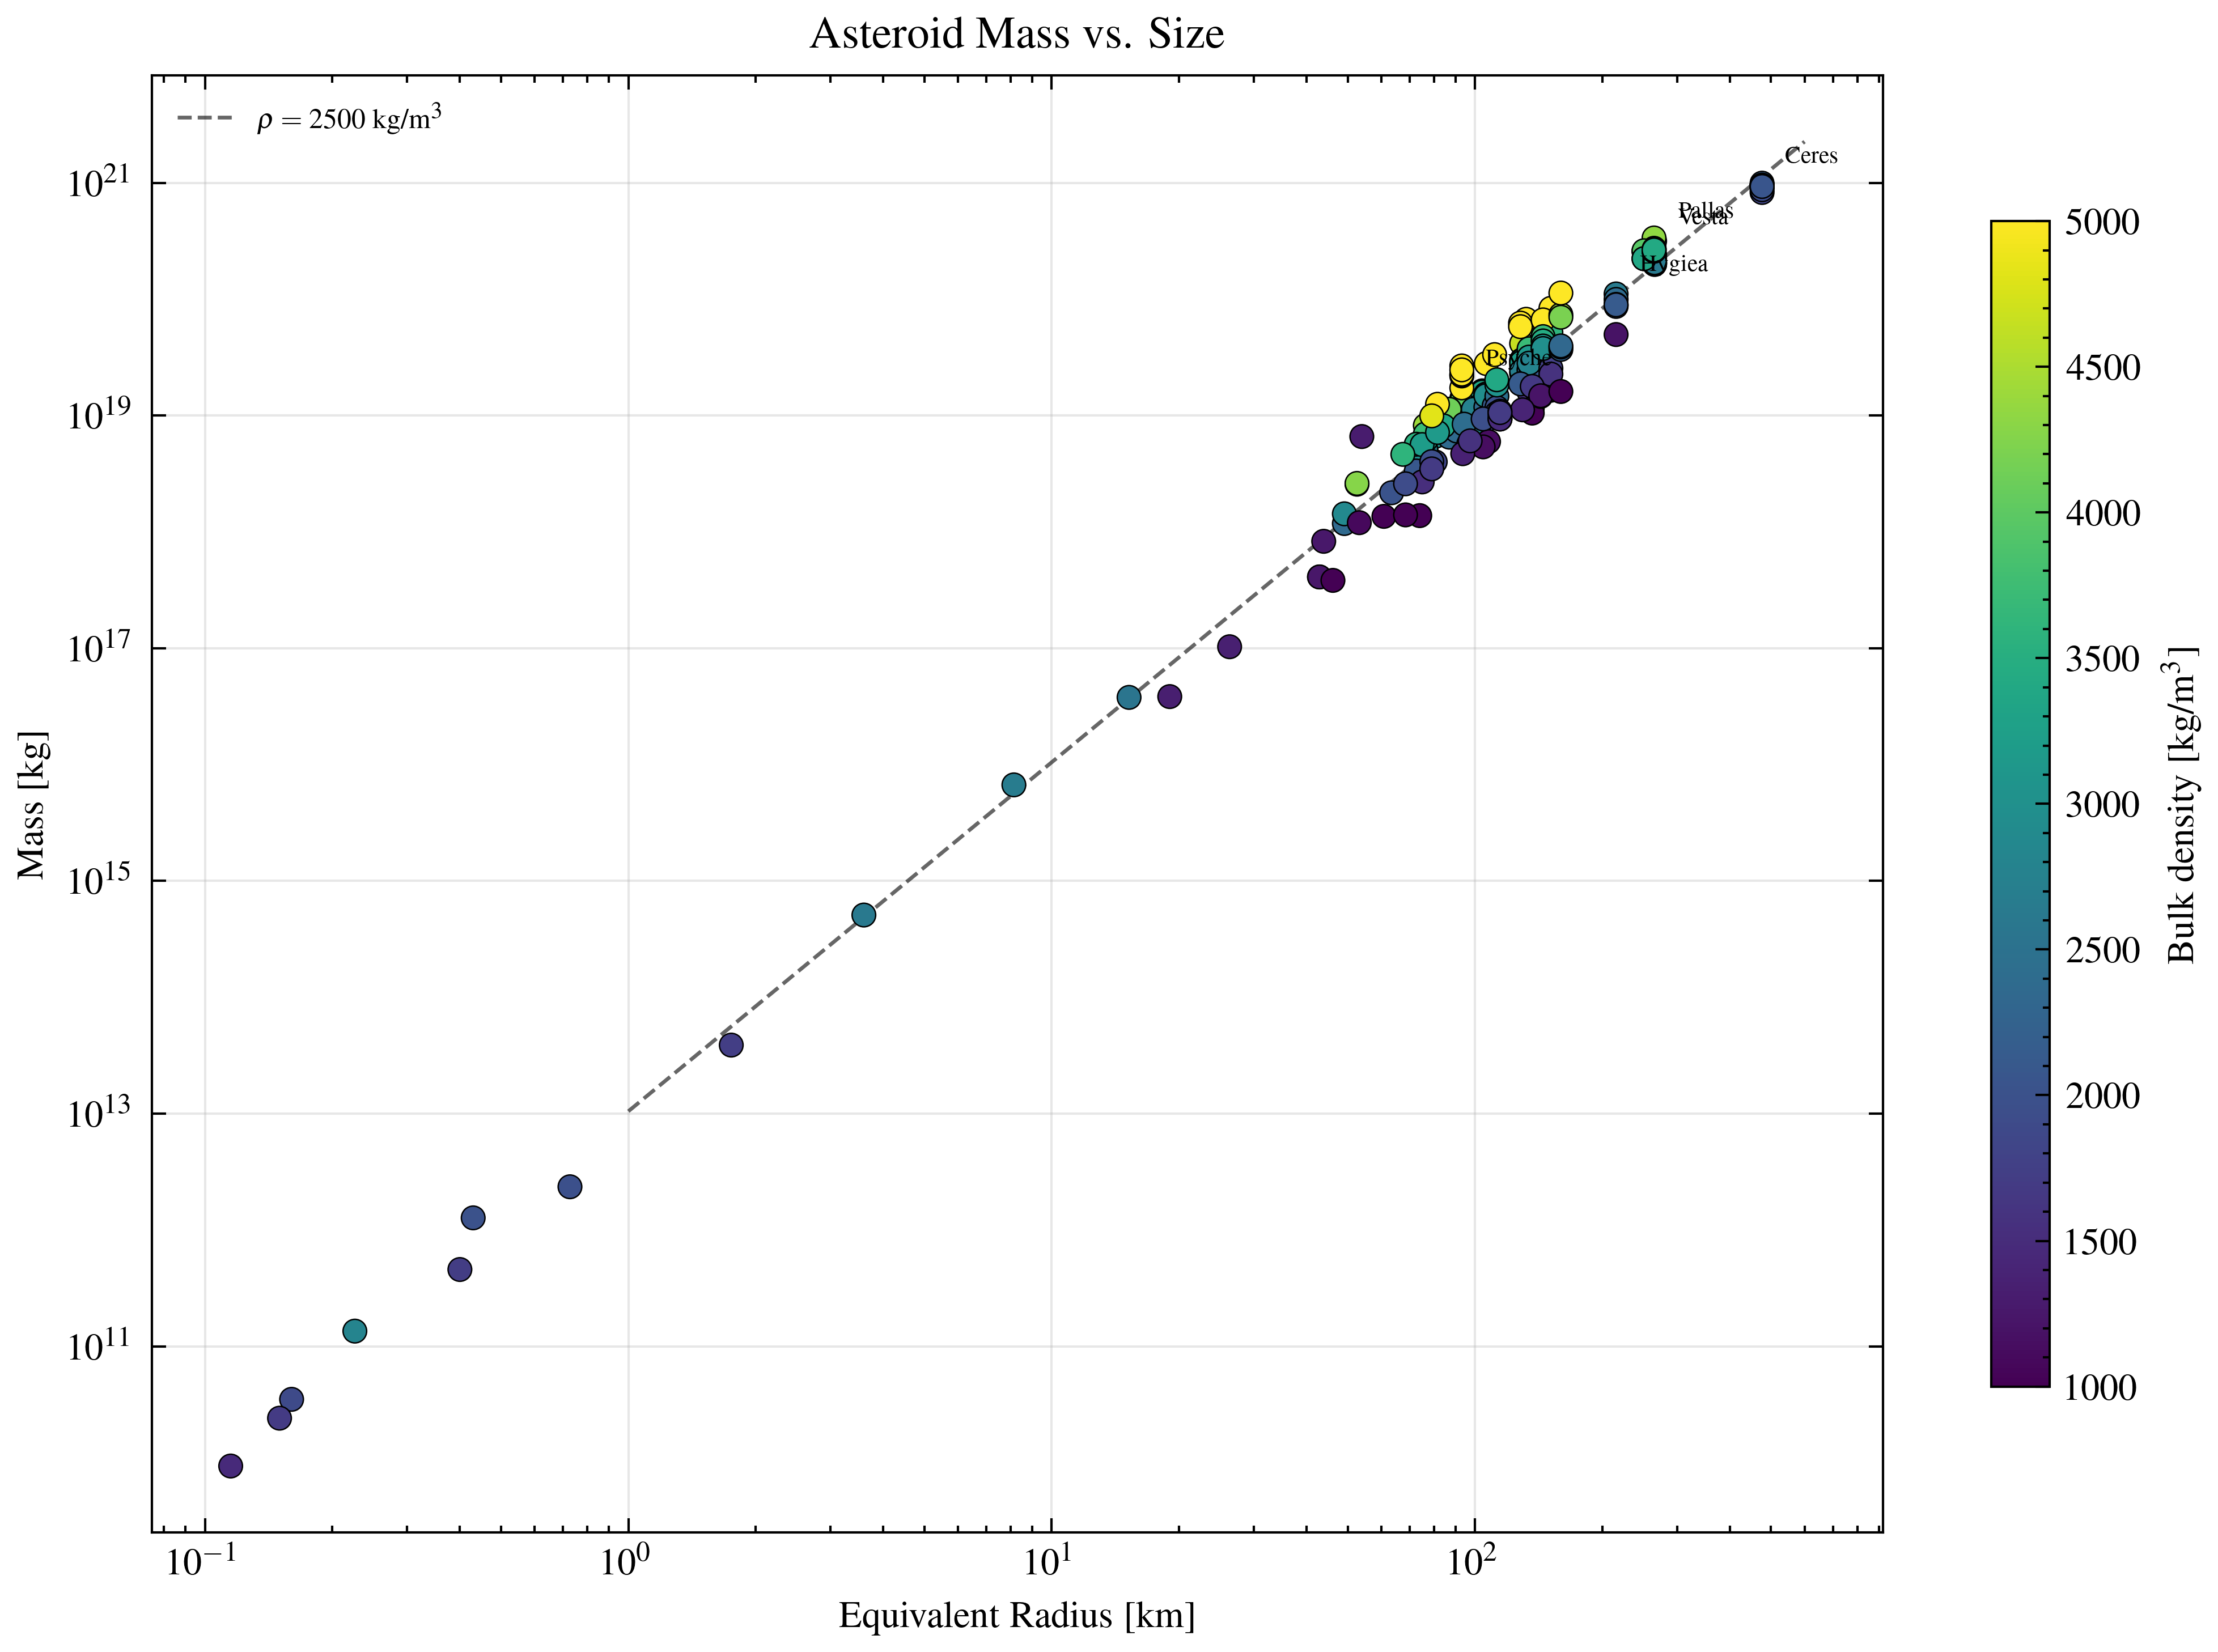

Asteroids with both mass and shape: 248


In [6]:
# Filter to asteroids with both mass and all three shape axes
df_both = df.filter(
    pl.col("mass_kg").is_not_null()
    & pl.col("axis_a").is_not_null()
    & pl.col("axis_b").is_not_null()
    & pl.col("axis_c").is_not_null()
)

mass_both = df_both["mass_kg"].to_numpy()  # already in kg
a_both = df_both["axis_a"].to_numpy()
b_both = df_both["axis_b"].to_numpy()
c_both = df_both["axis_c"].to_numpy()
R_both = (a_both * b_both * c_both) ** (1.0 / 3.0) / 2.0  # radius in km (axes are diameters)

# Density for coloring in kg/m^3 (dataset is g/cm^3)
density_both = df_both["bulk_density"].to_numpy().astype(float) * 1000.0
has_density = ~np.isnan(density_both)

fig, ax = plt.subplots(figsize=(7, 5))

# Points without density data
if np.any(~has_density):
    ax.scatter(
        R_both[~has_density],
        mass_both[~has_density],
        s=15,
        c="grey",
        alpha=0.5,
        edgecolors="k",
        linewidths=0.3,
        label="No density data",
        zorder=2,
    )

# Points with density data (colored)
if np.any(has_density):
    sc = ax.scatter(
        R_both[has_density],
        mass_both[has_density],
        s=25,
        c=density_both[has_density],
        cmap="viridis",
        edgecolors="k",
        linewidths=0.3,
        zorder=3,
        vmin=1000.0,
        vmax=5000.0,
    )
    fig.colorbar(sc, ax=ax, label=r"Bulk density [kg/m$^3$]", shrink=0.8)

# Reference line: M = (4/3) pi rho R^3 for rho = 2500 kg/m^3
R_ref = np.logspace(np.log10(1), np.log10(600), 100)  # km
rho_ref = 2500.0  # kg/m^3
R_ref_m = R_ref * 1e3  # convert km to m
M_ref = (4.0 / 3.0) * np.pi * rho_ref * R_ref_m**3  # kg
ax.plot(R_ref, M_ref, "k--", linewidth=0.8, alpha=0.6, label=r"$\rho = 2500$ kg/m$^3$")

# Annotate notable asteroids
notable = {"Ceres": 1, "Vesta": 4, "Pallas": 2, "Hygiea": 10, "Psyche": 16}
for name, number in notable.items():
    mask = df_both["ast_number"].to_numpy() == number
    if np.any(mask):
        idx = np.argmax(mask)
        ax.annotate(
            name,
            (R_both[idx], mass_both[idx]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=5,
        )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Equivalent Radius [km]")
ax.set_ylabel("Mass [kg]")
ax.set_title("Asteroid Mass vs. Size")
ax.legend(fontsize=6, loc="upper left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Asteroids with both mass and shape: {len(R_both)}")

## Summary Statistics

In [7]:
print("Dataset summary:")
print(f"  Total records:              {df.shape[0]}")
print(f"  With mass:                  {df.filter(pl.col('mass_kg').is_not_null()).shape[0]}")
print(f"  With bulk density:          {df.filter(pl.col('bulk_density').is_not_null()).shape[0]}")
print(f"  With shape (all 3 axes):    {df_shape.shape[0]}")
print(f"  With mass + shape:          {df_both.shape[0]}")
print()

# Top 5 most massive
top5 = df.sort("mass_kg", descending=True, nulls_last=True).head(5)
print("Top 5 most massive asteroids:")
print(top5.select(["ast_number", "ast_name", "mass_kg", "bulk_density"]))

Dataset summary:
  Total records:              248
  With mass:                  248
  With bulk density:          248
  With shape (all 3 axes):    248
  With mass + shape:          248

Top 5 most massive asteroids:
shape: (5, 4)
┌────────────┬──────────┬───────────┬──────────────┐
│ ast_number ┆ ast_name ┆ mass_kg   ┆ bulk_density │
│ ---        ┆ ---      ┆ ---       ┆ ---          │
│ i64        ┆ str      ┆ f64       ┆ f64          │
╞════════════╪══════════╪═══════════╪══════════════╡
│ 136199     ┆ Eris     ┆ 1.6600e22 ┆ 2.26         │
│ 134340     ┆ Pluto    ┆ 1.3000e22 ┆ 2.03         │
│ 136108     ┆ Haumea   ┆ 4.0000e21 ┆ -0.99        │
│ 50000      ┆ Quaoar   ┆ 1.6000e21 ┆ 4.2          │
│ 0          ┆ -        ┆ 1.5200e21 ┆ 1.63         │
└────────────┴──────────┴───────────┴──────────────┘


---

# JPL Small Body Database (SBDB)

The SBDB provides orbital elements and physical properties for ~875,000
asteroids. Unlike the ASTMass dataset (248 objects with detailed mass/density/shape),
the SBDB has `diameter` (km) for ~150,000 asteroids and `GM` (km$^3$/s$^2$) for
~40 objects. This gives us a much larger statistical sample for size distributions
and a complementary view of the most massive asteroids.

We convert GM to mass via $M = \mathrm{GM} / G$ where
$G = 6.674 \times 10^{-11}$ m$^3$ kg$^{-1}$ s$^{-2}$.

In [8]:
sbdb = load_sbdb_asteroids()

print(f"Total SBDB records: {sbdb.shape[0]}")
print("\nNon-null counts for physical property columns:")
for col in ["full_name", "number", "name", "diameter", "GM"]:
    n_valid = sbdb[col].drop_nulls().len()
    print(f"  {col:<15} {n_valid:>7}")

# Gravitational constant in km^3 / (kg * s^2)
G_KM3 = 6.67430e-20

# Derive mass from GM where available
sbdb_gm = sbdb.filter(pl.col("GM").is_not_null())
gm_vals = sbdb_gm["GM"].to_numpy()  # km^3/s^2
mass_from_gm = gm_vals / G_KM3  # kg

print(f"\nAsteroids with GM:       {len(gm_vals)}")
print(f"Asteroids with diameter: {sbdb.filter(pl.col('diameter').is_not_null()).shape[0]}")

Total SBDB records: 875150

Non-null counts for physical property columns:
  full_name        875150
  number           875150
  name              25873
  diameter         135165
  GM                   17

Asteroids with GM:       17
Asteroids with diameter: 135165


## SBDB Diameter Distribution

The SBDB `diameter` column is in km.  With over 100,000 asteroids having
measured or estimated diameters, we get a much fuller picture of the
asteroid size distribution than the 248-object ASTMass dataset.

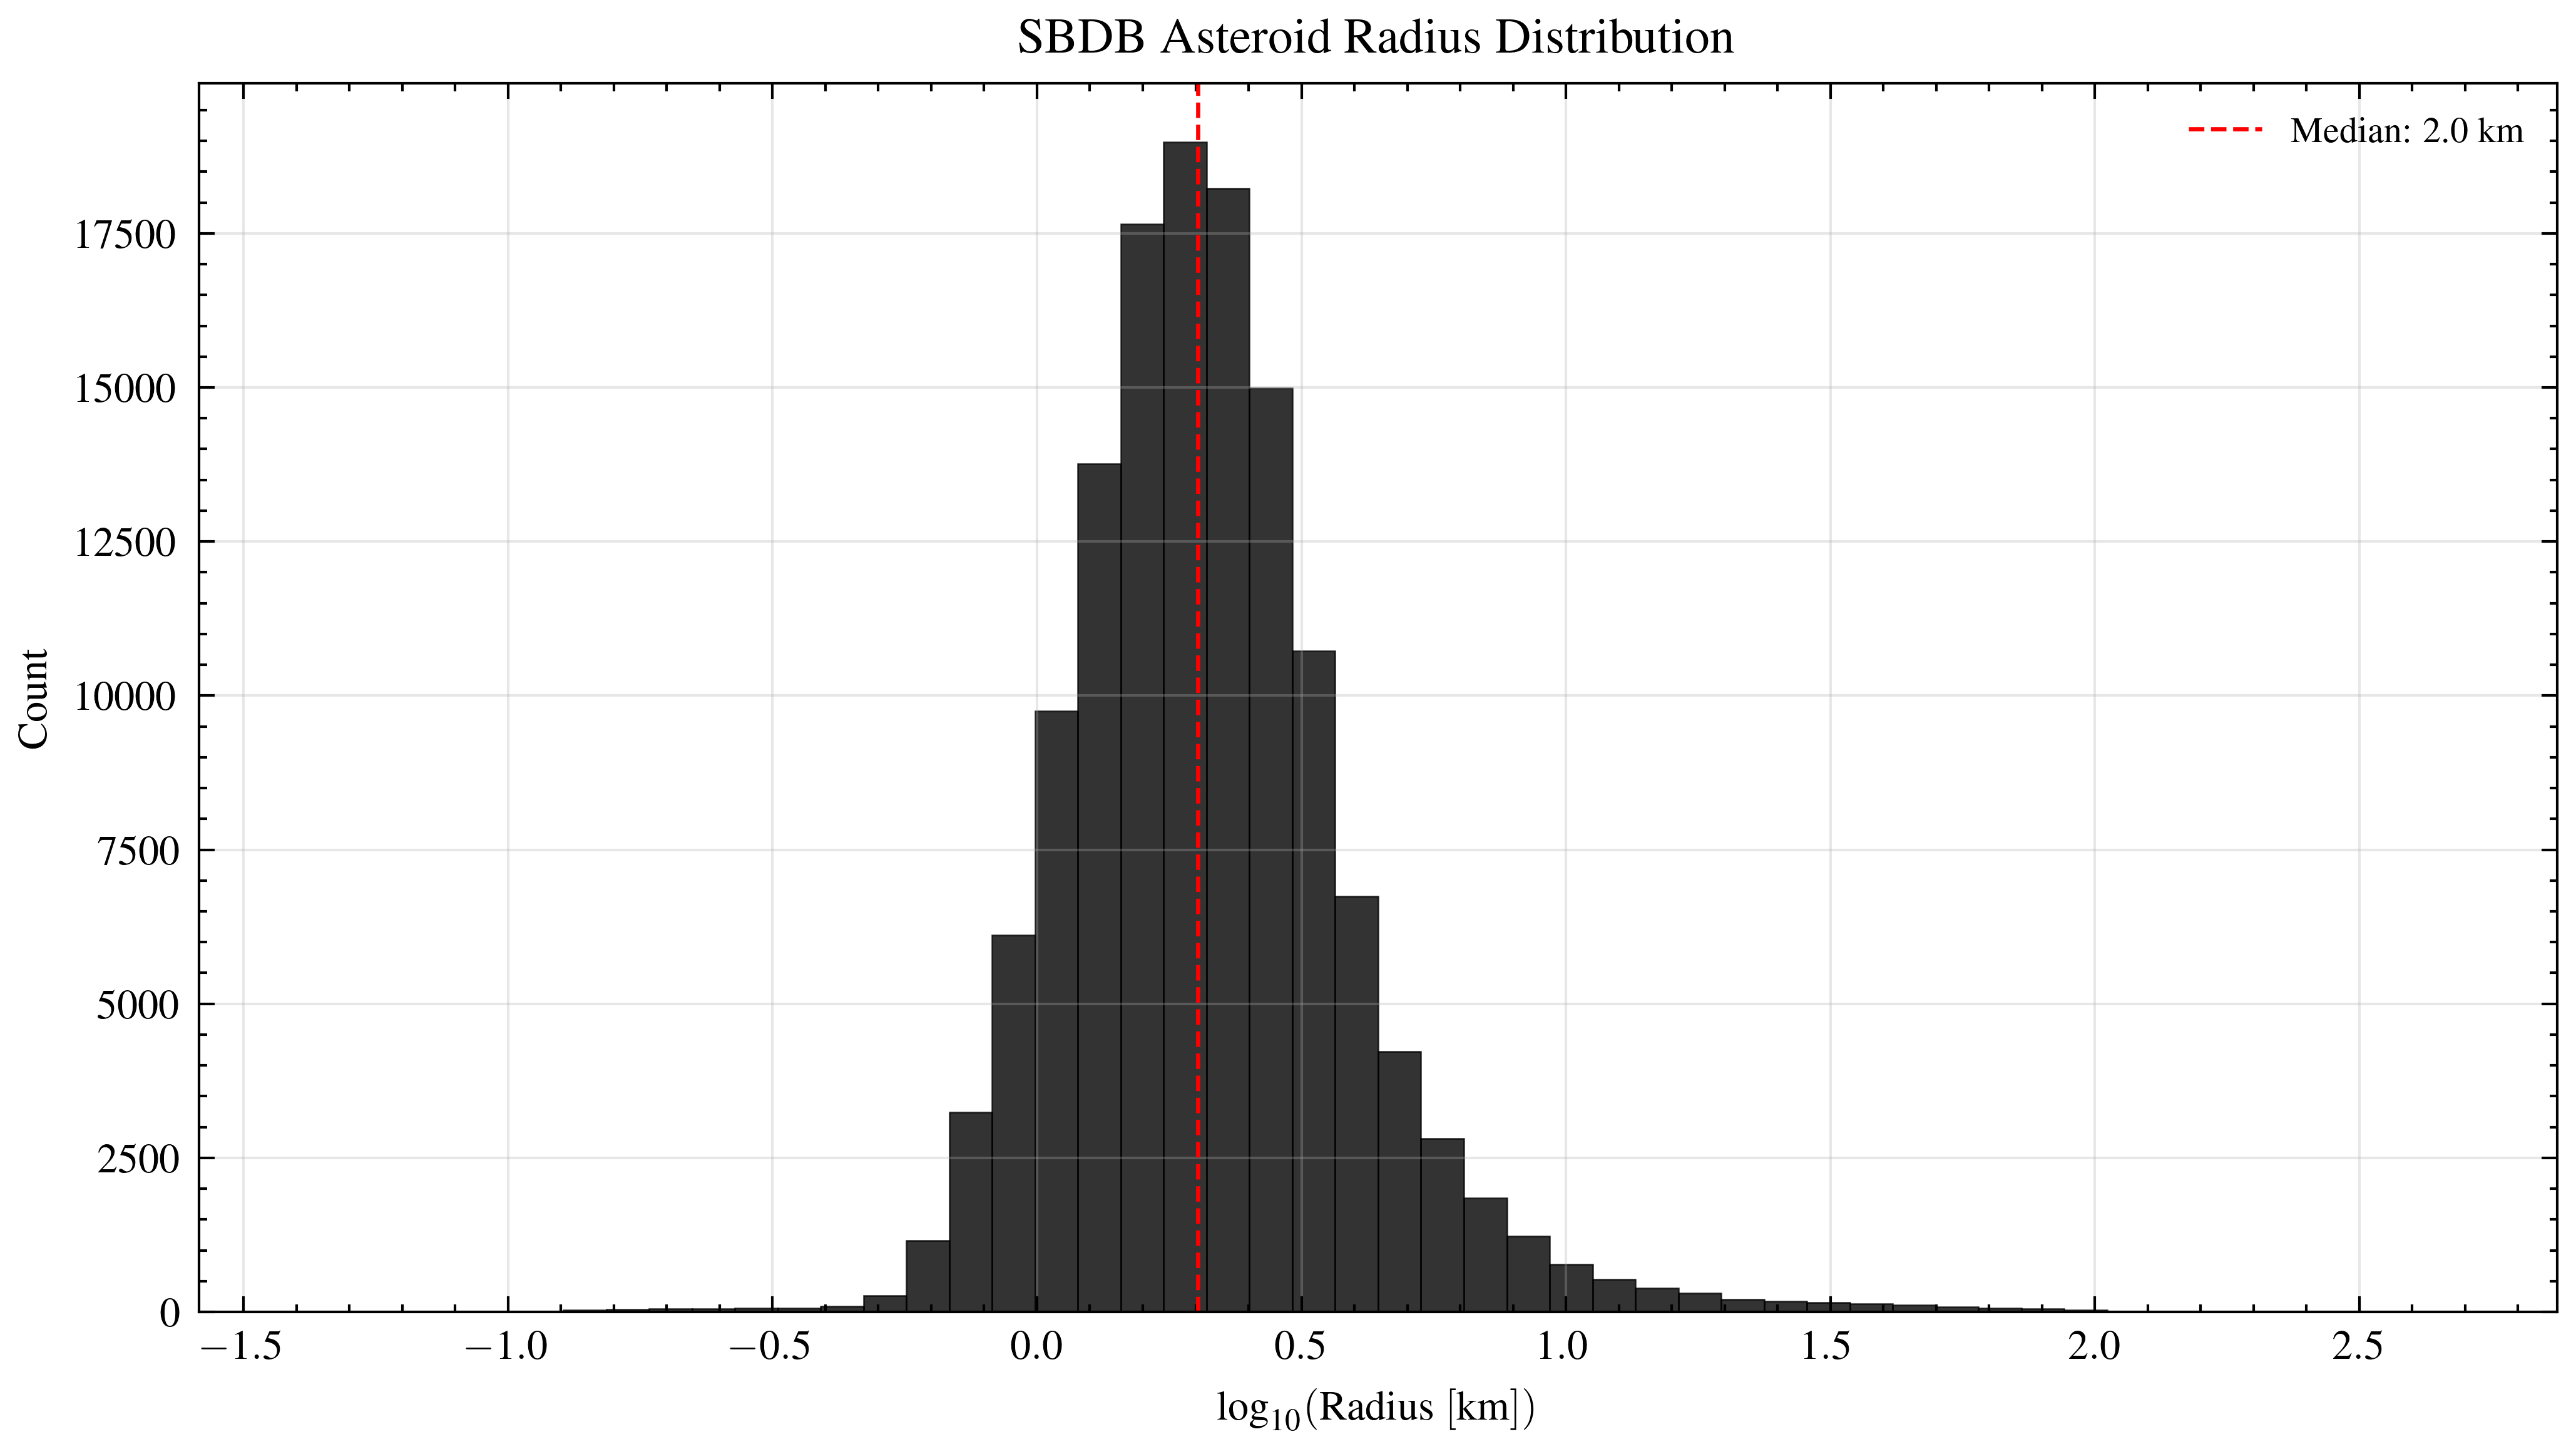

Asteroids with diameter data: 135165
Diameter range: 0.083 to 939.4 km
Radius range: 0.042 to 469.7 km


In [9]:
sbdb_diam = sbdb.filter(pl.col("diameter").is_not_null())
diameters = sbdb_diam["diameter"].to_numpy()
radii_sbdb = diameters / 2.0
log_radii_sbdb = np.log10(radii_sbdb)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(log_radii_sbdb, bins=50, edgecolor="k", linewidth=0.3, alpha=0.8)
median_log_r = np.median(log_radii_sbdb)
ax.axvline(
    median_log_r,
    color="red",
    linestyle="--",
    linewidth=0.8,
    label=f"Median: {10**median_log_r:.1f} km",
)
ax.set_xlabel(r"$\log_{10}(\mathrm{Radius\ [km]})$")
ax.set_ylabel("Count")
ax.set_title("SBDB Asteroid Radius Distribution")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Asteroids with diameter data: {len(diameters)}")
print(f"Diameter range: {diameters.min():.3f} to {diameters.max():.1f} km")
print(f"Radius range: {radii_sbdb.min():.3f} to {radii_sbdb.max():.1f} km")

## SBDB Mass Distribution (from GM)

Only a small subset of SBDB asteroids have measured GM values.
We convert these to mass and compare with the ASTMass dataset.

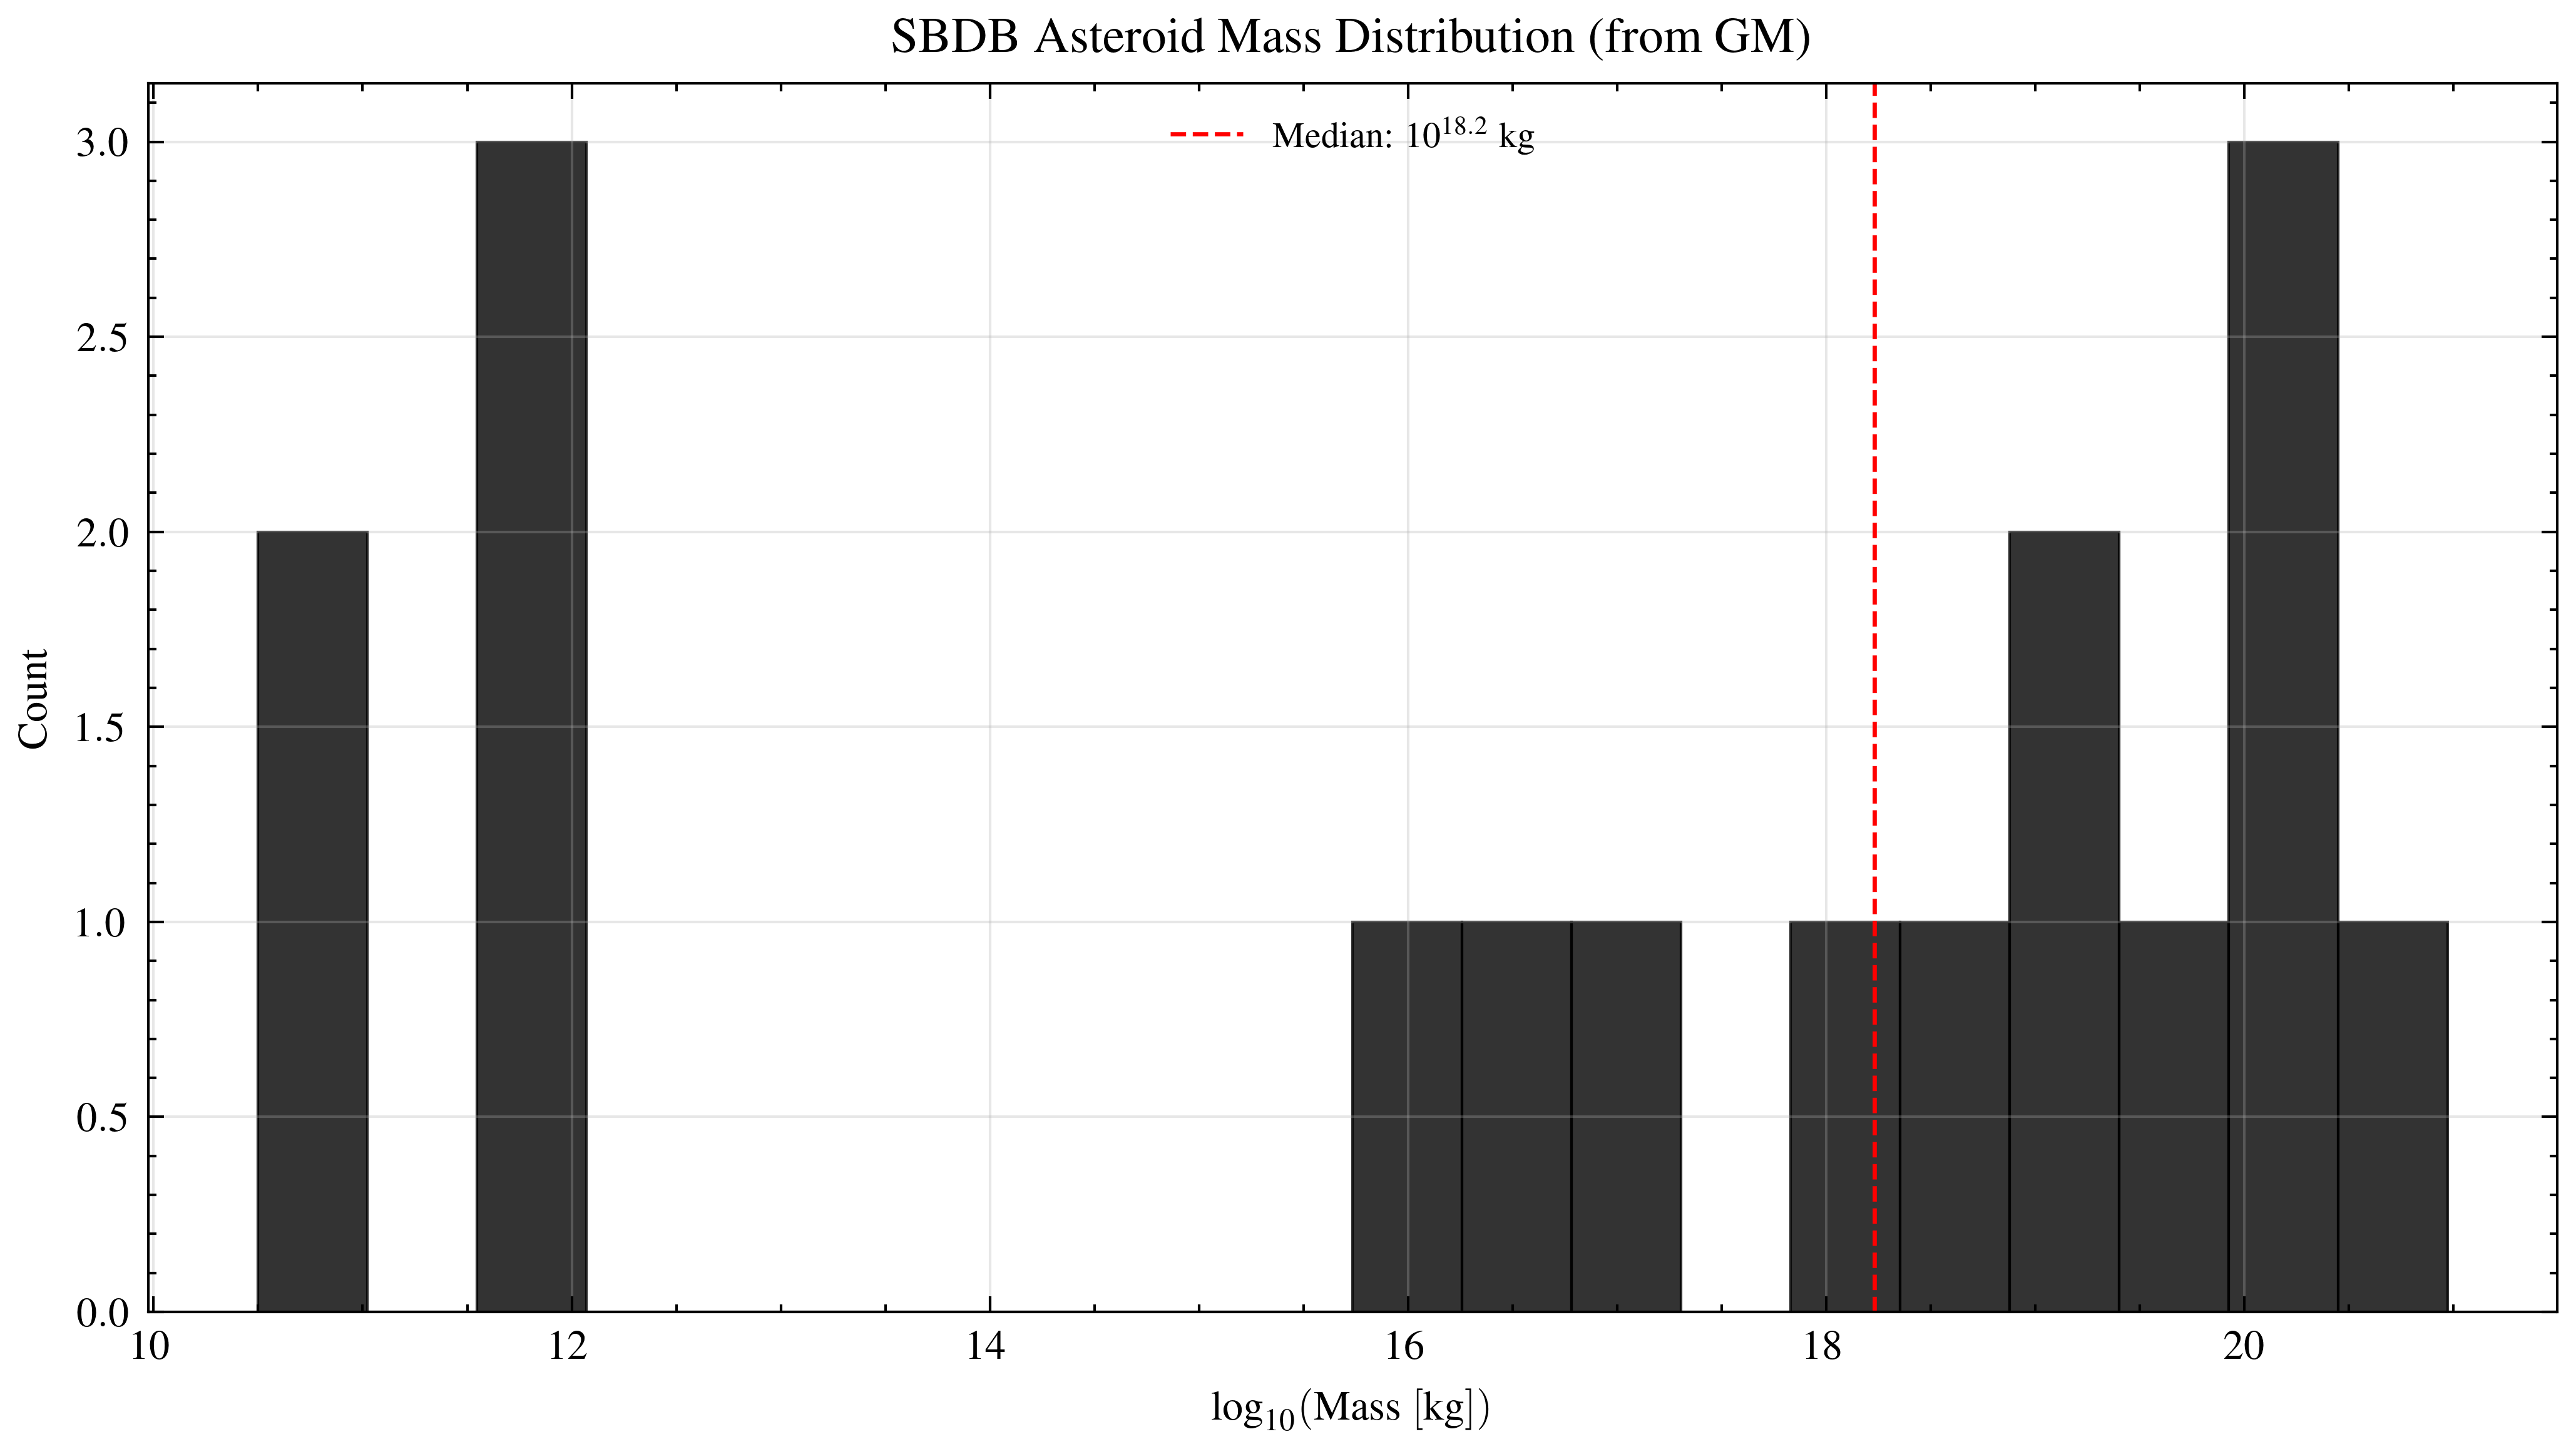

Asteroids with GM-derived mass: 17
Mass range: 3.15e+10 to 9.38e+20 kg

SBDB asteroids with GM:
shape: (10, 4)
┌────────┬────────────┬───────────┬──────────┐
│ number ┆ name       ┆ GM        ┆ diameter │
│ ---    ┆ ---        ┆ ---       ┆ ---      │
│ str    ┆ str        ┆ f64       ┆ f64      │
╞════════╪════════════╪═══════════╪══════════╡
│ 1      ┆ Ceres      ┆ 62.6284   ┆ 939.4    │
│ 4      ┆ Vesta      ┆ 17.288284 ┆ 522.77   │
│ 2      ┆ Pallas     ┆ 13.63     ┆ 513.0    │
│ 10     ┆ Hygiea     ┆ 7.0       ┆ 407.12   │
│ 704    ┆ Interamnia ┆ 5.0       ┆ 306.313  │
│ 16     ┆ Psyche     ┆ 1.601     ┆ 222.0    │
│ 107    ┆ Camilla    ┆ 0.7475    ┆ 210.37   │
│ 22     ┆ Kalliope   ┆ 0.491     ┆ 167.536  │
│ 21     ┆ Lutetia    ┆ 0.1134    ┆ 98.0     │
│ 253    ┆ Mathilde   ┆ 0.00689   ┆ 52.8     │
└────────┴────────────┴───────────┴──────────┘


In [10]:
log_mass_sbdb = np.log10(mass_from_gm)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(log_mass_sbdb, bins=20, edgecolor="k", linewidth=0.5, alpha=0.8)
median_log_m = np.median(log_mass_sbdb)
ax.axvline(
    median_log_m,
    color="red",
    linestyle="--",
    linewidth=0.8,
    label=f"Median: $10^{{{median_log_m:.1f}}}$ kg",
)
ax.set_xlabel(r"$\log_{10}(\mathrm{Mass\ [kg]})$")
ax.set_ylabel("Count")
ax.set_title("SBDB Asteroid Mass Distribution (from GM)")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Asteroids with GM-derived mass: {len(mass_from_gm)}")
print(f"Mass range: {mass_from_gm.min():.2e} to {mass_from_gm.max():.2e} kg")

# Show the named objects
print("\nSBDB asteroids with GM:")
print(
    sbdb_gm.select(["number", "name", "GM", "diameter"])
    .sort("GM", descending=True)
    .head(10)
)

## SBDB Mass vs. Radius

For SBDB asteroids that have both `GM` and `diameter`, we can plot mass
versus radius and compare against the $\rho = 2500$ kg/m$^3$ reference line.

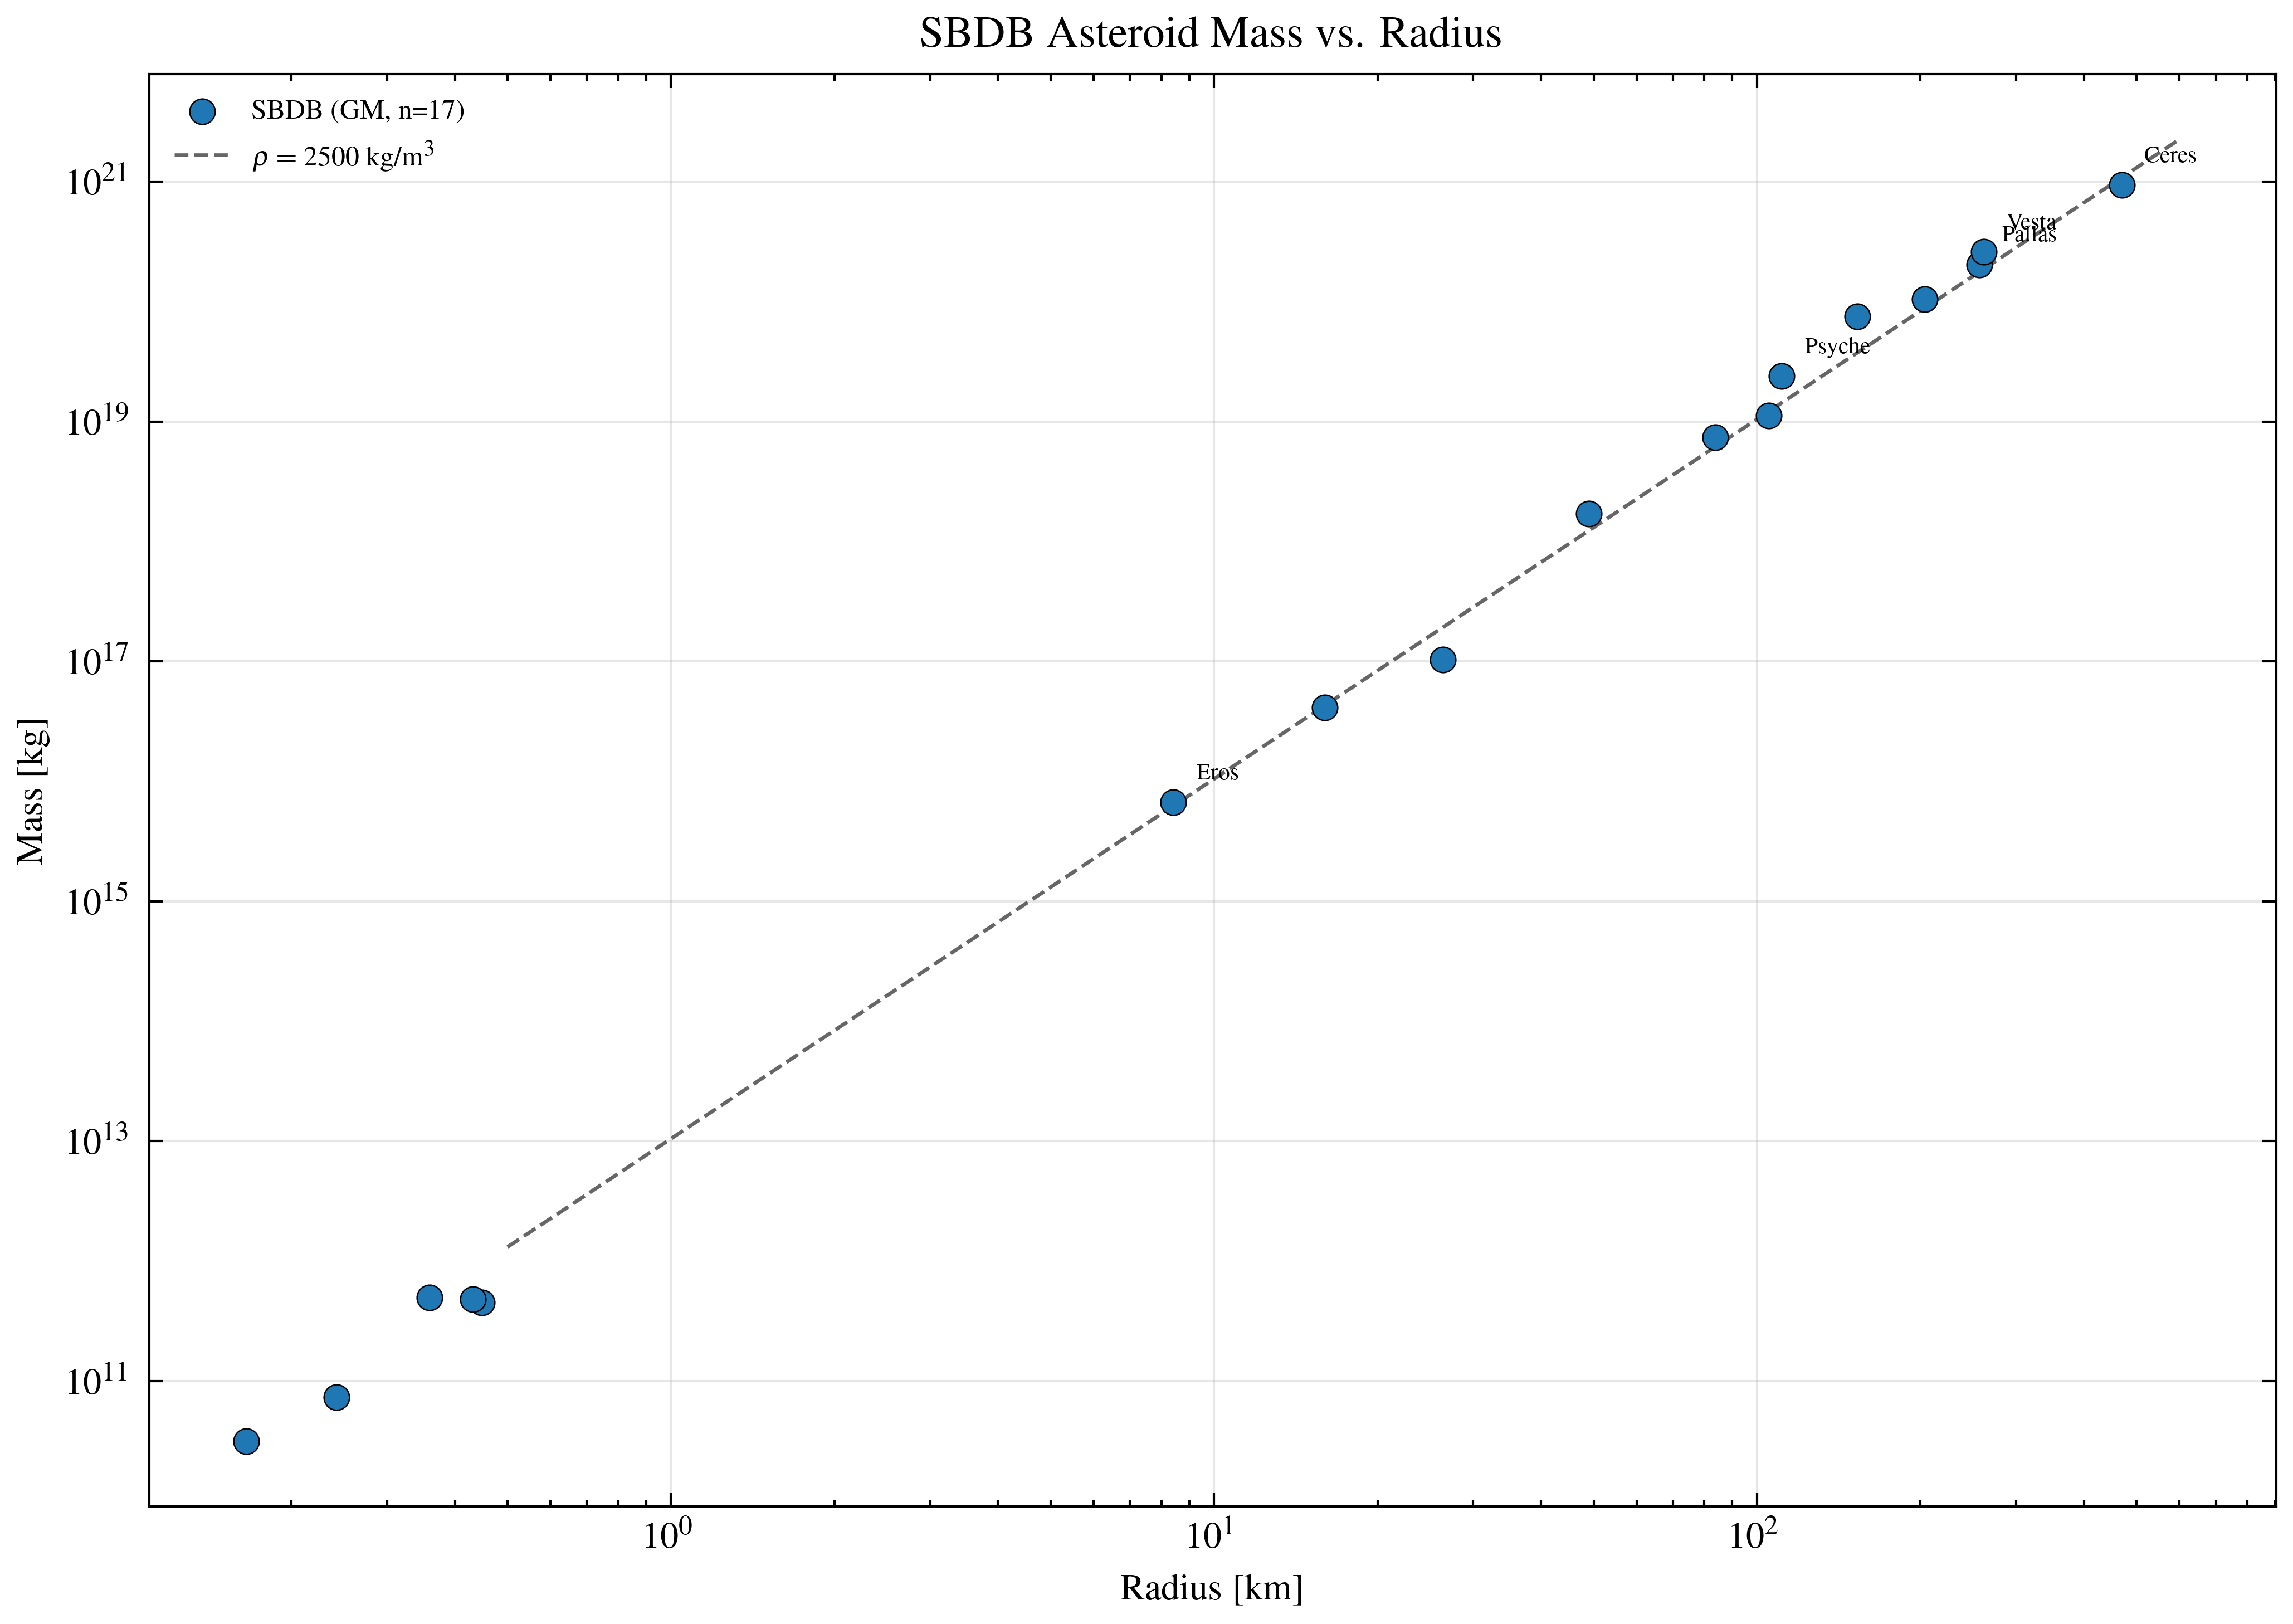

SBDB asteroids with both GM and diameter: 17


In [11]:
# Filter SBDB to asteroids with both GM and diameter
sbdb_both = sbdb.filter(pl.col("GM").is_not_null() & pl.col("diameter").is_not_null())
sbdb_mass = sbdb_both["GM"].to_numpy() / G_KM3  # kg
sbdb_radius = sbdb_both["diameter"].to_numpy() / 2.0  # km

fig, ax = plt.subplots(figsize=(7, 5))

# SBDB points
ax.scatter(
    sbdb_radius,
    sbdb_mass,
    s=30,
    c="tab:blue",
    edgecolors="k",
    linewidths=0.3,
    label=f"SBDB (GM, n={len(sbdb_mass)})",
    zorder=3,
)

# Reference line: M = (4/3) pi rho R^3 for rho = 2500 kg/m^3
R_ref = np.logspace(np.log10(0.5), np.log10(600), 100)  # km
rho_ref = 2500.0  # kg/m^3
R_ref_m = R_ref * 1e3  # convert km to m
M_ref = (4.0 / 3.0) * np.pi * rho_ref * R_ref_m**3  # kg
ax.plot(R_ref, M_ref, "k--", linewidth=0.8, alpha=0.6, label=r"$\rho = 2500$ kg/m$^3$")

# Annotate notable SBDB asteroids
notable_sbdb = {"Ceres": "1", "Vesta": "4", "Pallas": "2", "Psyche": "16", "Eros": "433"}
numbers = sbdb_both["number"].to_list()
for name, num_str in notable_sbdb.items():
    if num_str in numbers:
        idx = numbers.index(num_str)
        ax.annotate(
            name,
            (sbdb_radius[idx], sbdb_mass[idx]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=5,
        )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Radius [km]")
ax.set_ylabel("Mass [kg]")
ax.set_title("SBDB Asteroid Mass vs. Radius")
ax.legend(fontsize=6, loc="upper left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"SBDB asteroids with both GM and diameter: {len(sbdb_mass)}")

## Combined: ASTMass vs. SBDB

Overlaying both datasets on the same mass-vs-radius plot highlights their
complementarity: ASTMass provides density-colored detail for 248 objects
while SBDB adds GM-derived masses for the most massive asteroids.

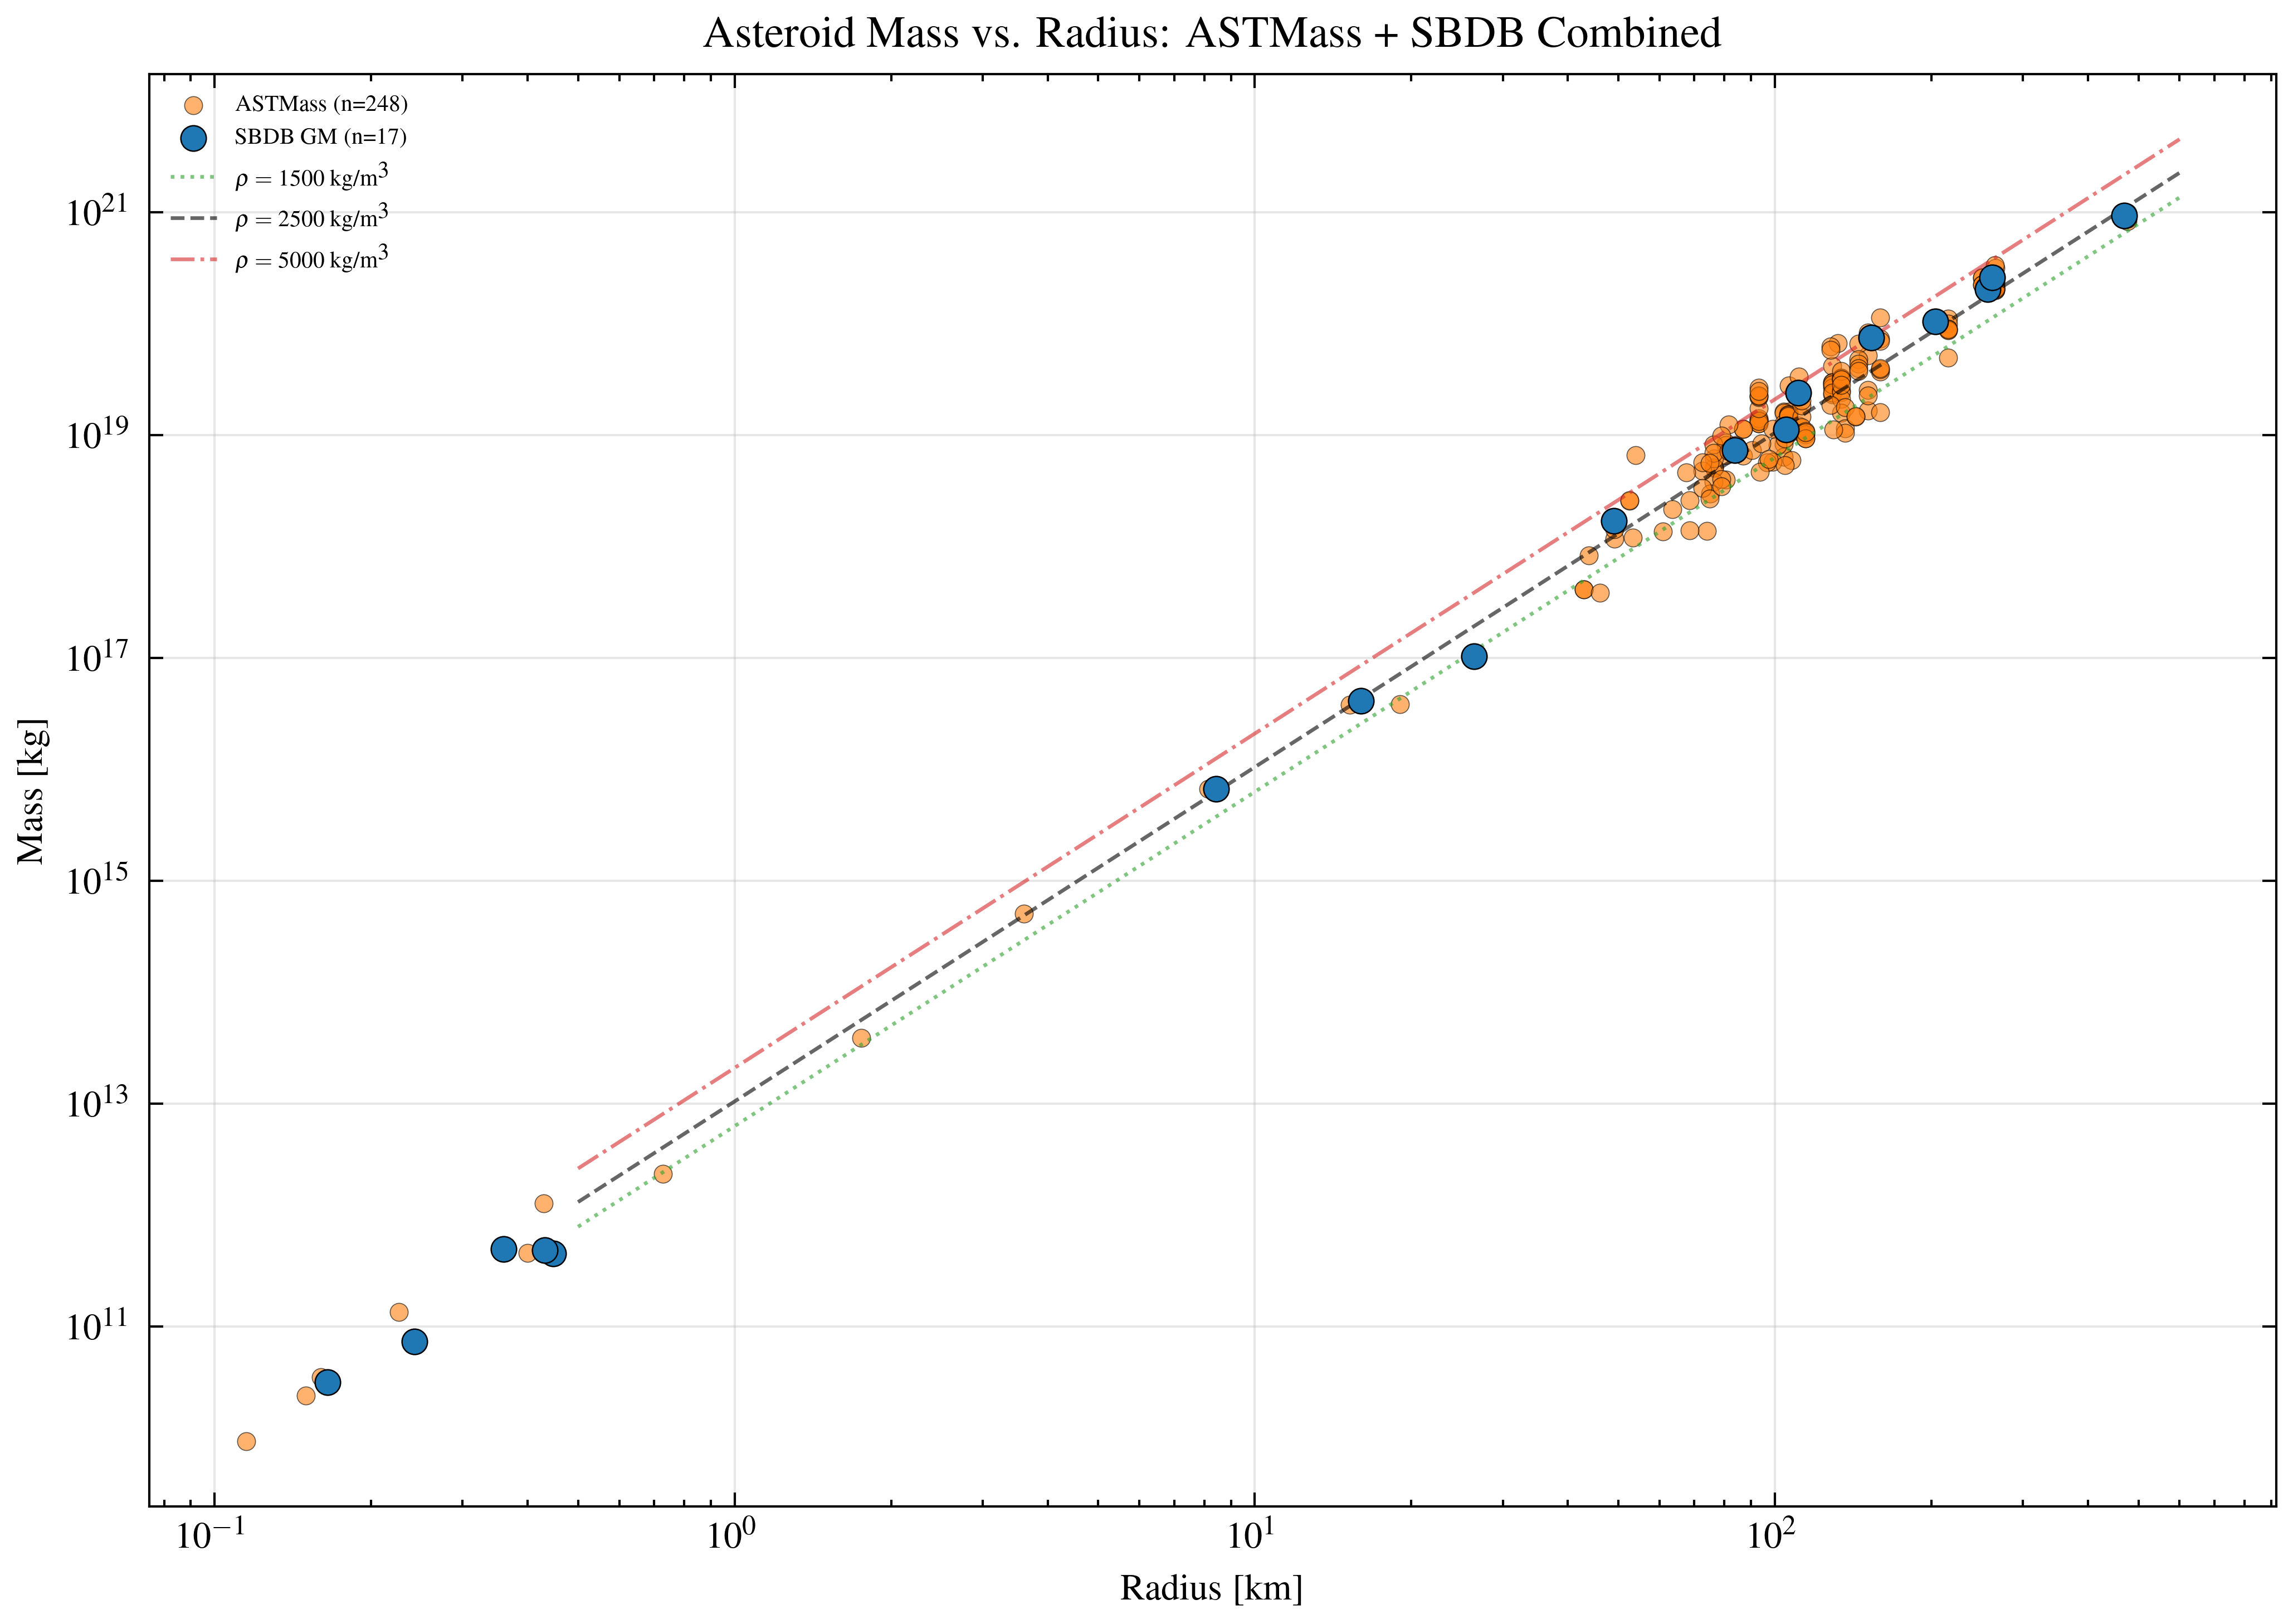

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

# ASTMass points (use data from earlier cells)
ax.scatter(
    R_both,
    mass_both,
    s=15,
    c="tab:orange",
    alpha=0.6,
    edgecolors="k",
    linewidths=0.2,
    label=f"ASTMass (n={len(R_both)})",
    zorder=2,
)

# SBDB points (GM-derived)
ax.scatter(
    sbdb_radius,
    sbdb_mass,
    s=30,
    c="tab:blue",
    edgecolors="k",
    linewidths=0.3,
    label=f"SBDB GM (n={len(sbdb_mass)})",
    zorder=3,
)

# Reference lines for different densities
for rho_val, ls, clr in [(1500.0, ":", "tab:green"), (2500.0, "--", "k"), (5000.0, "-.", "tab:red")]:
    R_ref = np.logspace(np.log10(0.5), np.log10(600), 100)
    R_ref_m = R_ref * 1e3
    M_ref = (4.0 / 3.0) * np.pi * rho_val * R_ref_m**3
    ax.plot(R_ref, M_ref, linestyle=ls, color=clr, linewidth=0.8, alpha=0.6,
            label=rf"$\rho = {rho_val:.0f}$ kg/m$^3$")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Radius [km]")
ax.set_ylabel("Mass [kg]")
ax.set_title("Asteroid Mass vs. Radius: ASTMass + SBDB Combined")
ax.legend(fontsize=5, loc="upper left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Radius Comparison: ASTMass vs. SBDB

Overlaying the radius distributions from both datasets shows how SBDB
extends coverage to much smaller asteroids that lack mass measurements.

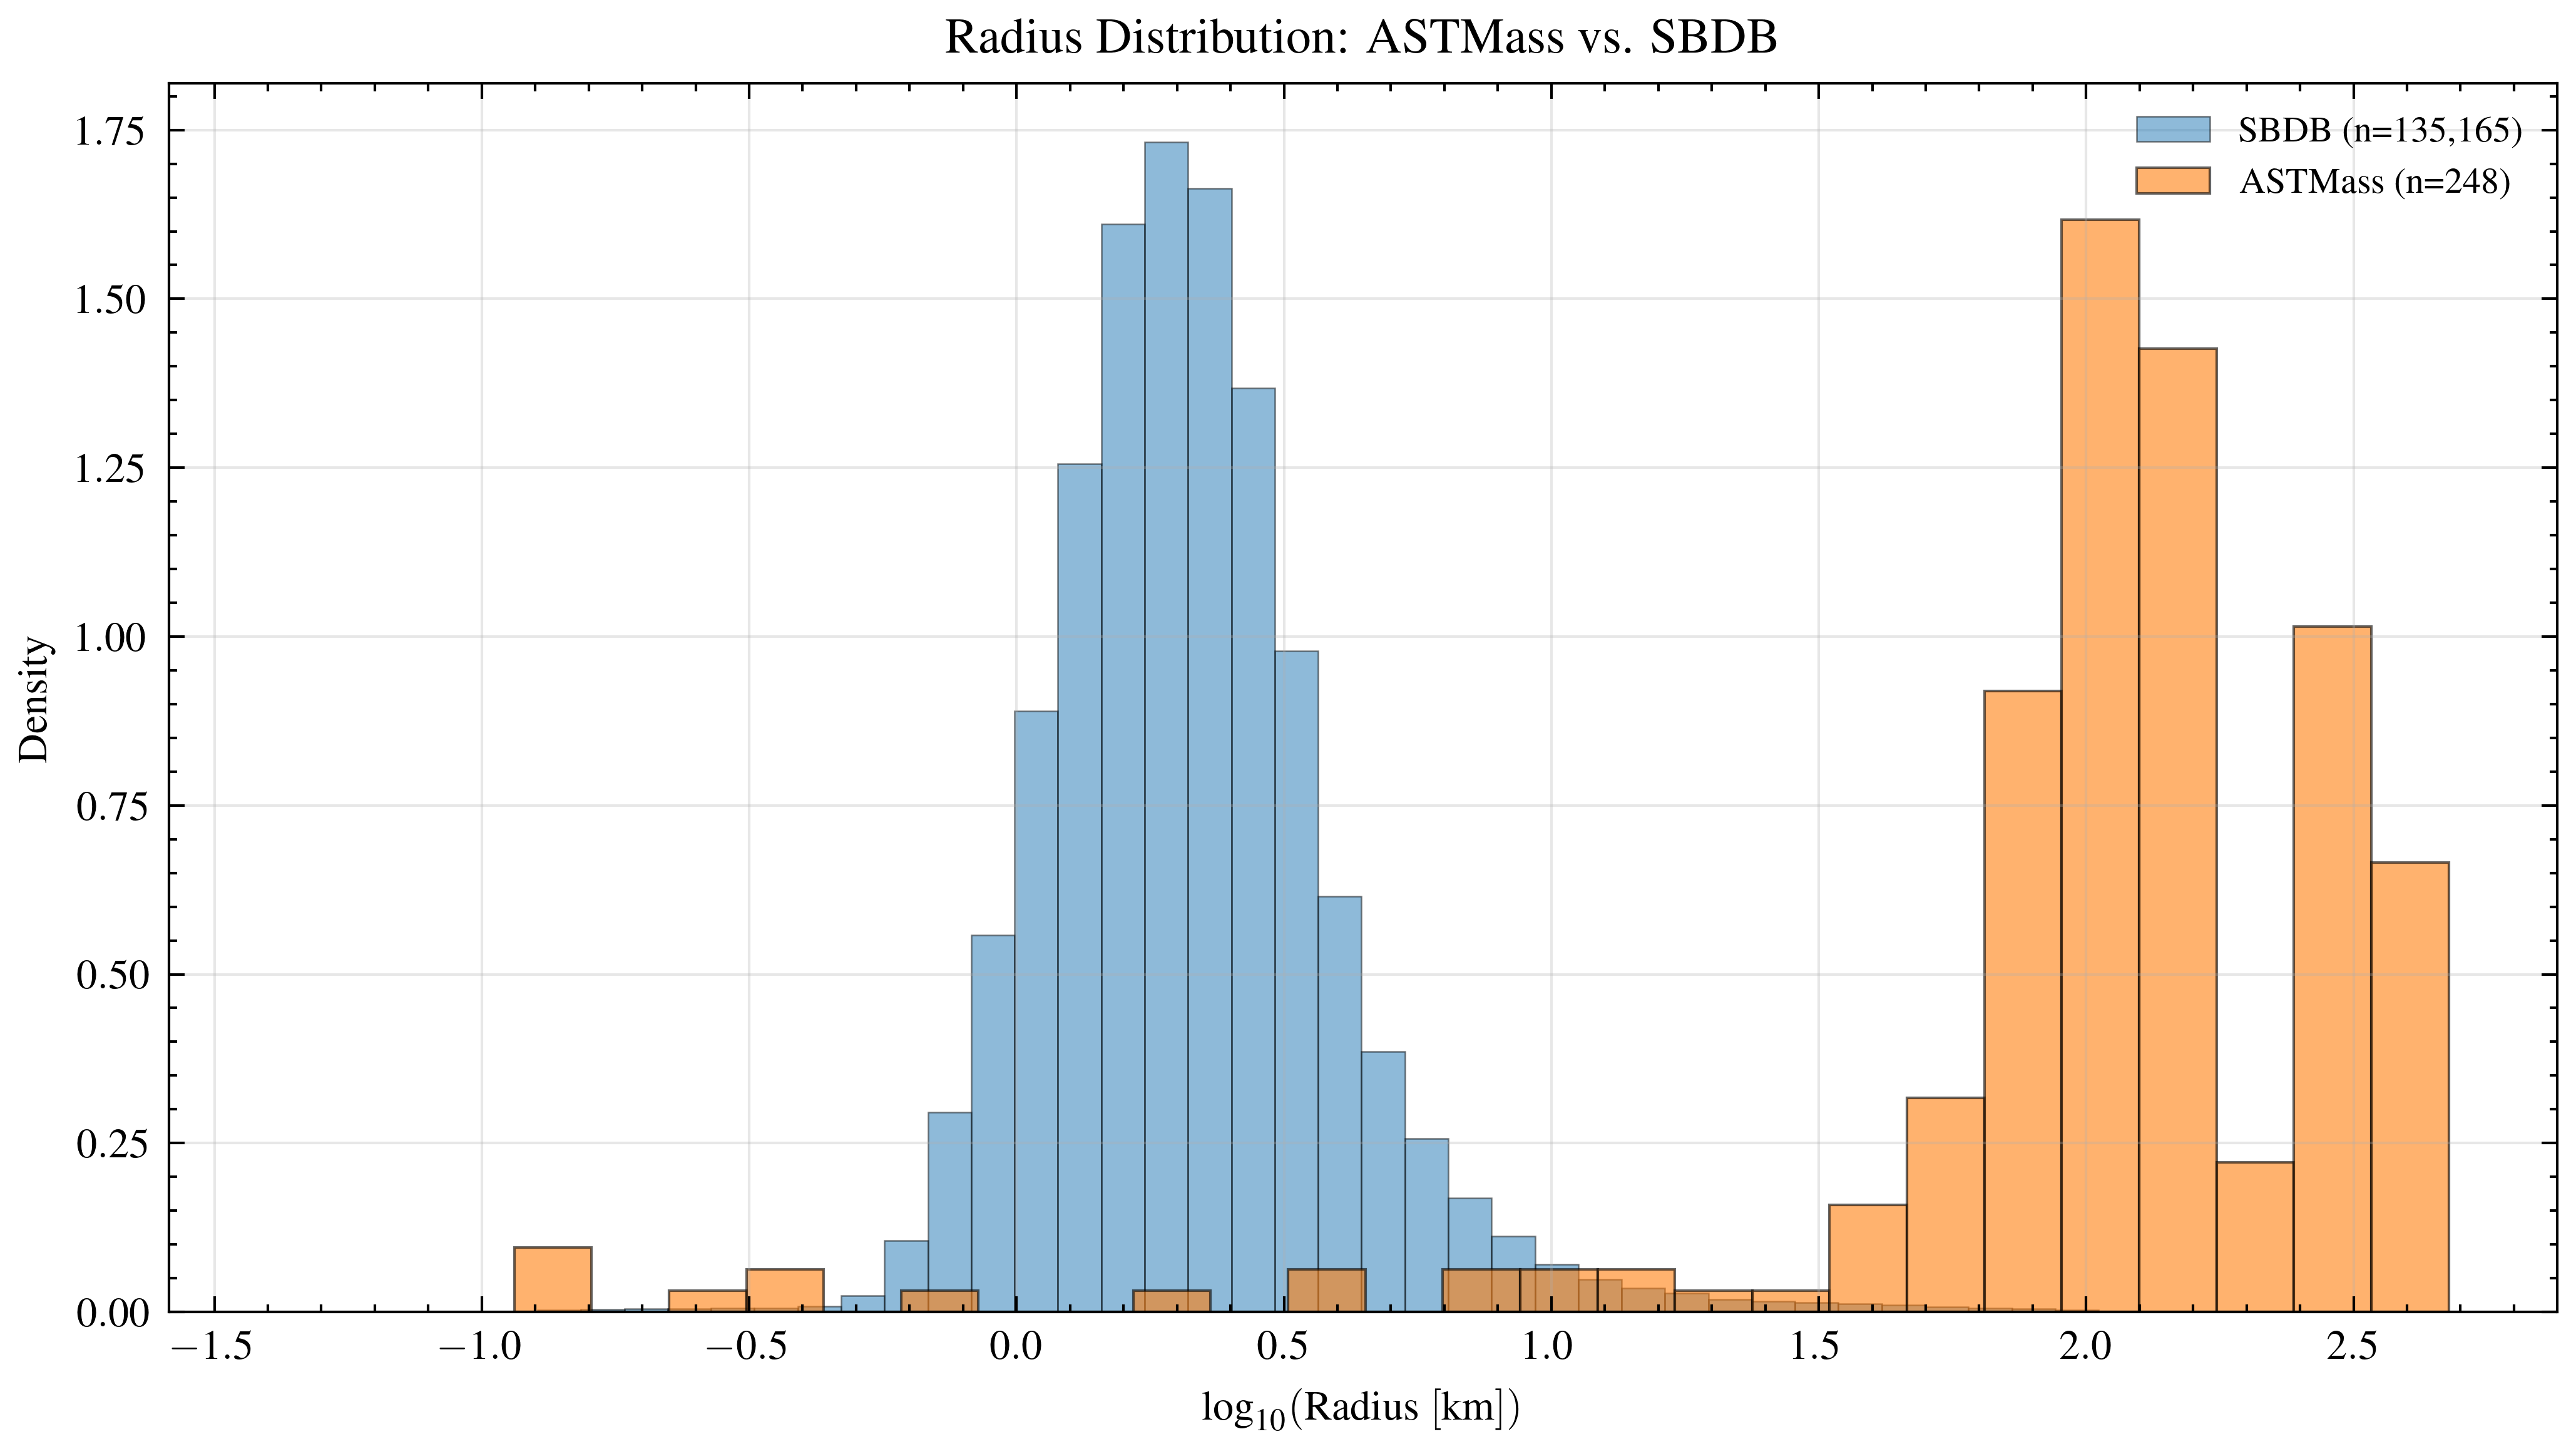

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))

# SBDB radius distribution (normalized for comparison)
ax.hist(
    log_radii_sbdb,
    bins=50,
    edgecolor="k",
    linewidth=0.3,
    alpha=0.5,
    density=True,
    label=f"SBDB (n={len(radii_sbdb):,})",
    color="tab:blue",
)

# ASTMass radius distribution (normalized)
ax.hist(
    log_R,
    bins=25,
    edgecolor="k",
    linewidth=0.5,
    alpha=0.6,
    density=True,
    label=f"ASTMass (n={len(R_eq)})",
    color="tab:orange",
)

ax.set_xlabel(r"$\log_{10}(\mathrm{Radius\ [km]})$")
ax.set_ylabel("Density")
ax.set_title("Radius Distribution: ASTMass vs. SBDB")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## SBDB Summary Statistics

In [ ]:
print("SBDB dataset summary:")
print(f"  Total records:              {sbdb.shape[0]:>10,}")
print(f"  With diameter:              {sbdb.filter(pl.col('diameter').is_not_null()).shape[0]:>10,}")
print(f"  With GM:                    {sbdb.filter(pl.col('GM').is_not_null()).shape[0]:>10,}")
print(f"  With both GM + diameter:    {sbdb_both.shape[0]:>10,}")
print()

# Top 10 by GM
print("Top 10 SBDB asteroids by GM:")
top10 = (
    sbdb.filter(pl.col("GM").is_not_null())
    .with_columns((pl.col("GM") / G_KM3).alias("mass_kg"))
    .sort("GM", descending=True)
    .head(10)
)
print(top10.select(["number", "name", "diameter", "GM", "mass_kg"]))

SBDB dataset summary:
  Total records:                 875,150
  With diameter:                 135,165
  With GM:                            17
  With both GM + diameter:            17

Top 10 SBDB asteroids by GM:
shape: (10, 5)
┌────────┬────────────┬──────────┬───────────┬───────────┐
│ number ┆ name       ┆ diameter ┆ GM        ┆ mass_kg   │
│ ---    ┆ ---        ┆ ---      ┆ ---       ┆ ---       │
│ str    ┆ str        ┆ f64      ┆ f64       ┆ f64       │
╞════════╪════════════╪══════════╪═══════════╪═══════════╡
│ 1      ┆ Ceres      ┆ 939.4    ┆ 62.6284   ┆ 9.3835e20 │
│ 4      ┆ Vesta      ┆ 522.77   ┆ 17.288284 ┆ 2.5903e20 │
│ 2      ┆ Pallas     ┆ 513.0    ┆ 13.63     ┆ 2.0422e20 │
│ 10     ┆ Hygiea     ┆ 407.12   ┆ 7.0       ┆ 1.0488e20 │
│ 704    ┆ Interamnia ┆ 306.313  ┆ 5.0       ┆ 7.4914e19 │
│ 16     ┆ Psyche     ┆ 222.0    ┆ 1.601     ┆ 2.3988e19 │
│ 107    ┆ Camilla    ┆ 210.37   ┆ 0.7475    ┆ 1.1200e19 │
│ 22     ┆ Kalliope   ┆ 167.536  ┆ 0.491     ┆ 7.3566e18 │
│ 

: 